# E-Commerce Dataset Analysis
## Exploratory Data Analysis

**Dataset:** E Commerce Dataset.xlsx  
**Date:** February 2026  
**Objective:** Analyze customer behavior, purchase patterns, and retention metrics

## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Load Dataset

In [31]:
# Inspect the Excel file structure
xl_file = pd.ExcelFile('E Commerce Dataset.xlsx')
print(f" Sheet names in the workbook: {xl_file.sheet_names}\n")

# Load the actual E-Commerce data from the 'E Comm' sheet
print("=" * 80)
print("Loading E-Commerce Data...")
print("=" * 80)

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

 Sheet names in the workbook: ['Data Dict', 'E Comm']

Loading E-Commerce Data...
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


## 3. Initial Data Exploration

In [32]:
# Dataset information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13

In [33]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe(include='all').T

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,"5,630.00",NaN,NaN,NaN,"52,815.50","1,625.39","50,001.00","51,408.25","52,815.50","54,222.75","55,630.00"
Churn,"5,630.00",NaN,NaN,NaN,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,"5,366.00",NaN,NaN,NaN,10.19,8.56,0.00,2.00,9.00,16.00,61.00
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,"5,630.00",NaN,NaN,NaN,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,"5,379.00",NaN,NaN,NaN,15.64,8.53,5.00,9.00,14.00,20.00,127.00
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,"5,375.00",NaN,NaN,NaN,2.93,0.72,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,"5,630.00",NaN,NaN,NaN,3.69,1.02,1.00,3.00,4.00,4.00,6.00


In [34]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

print(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Data completeness: {(1 - df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%")

MISSING VALUES ANALYSIS
                                                  Column  Missing_Count  \
DaySinceLastOrder                      DaySinceLastOrder            307   
OrderAmountHikeFromlastYear  OrderAmountHikeFromlastYear            265   
Tenure                                            Tenure            264   
OrderCount                                    OrderCount            258   
CouponUsed                                    CouponUsed            256   
HourSpendOnApp                            HourSpendOnApp            255   
WarehouseToHome                          WarehouseToHome            251   

                             Missing_Percentage  
DaySinceLastOrder                          5.45  
OrderAmountHikeFromlastYear                4.71  
Tenure                                     4.69  
OrderCount                                 4.58  
CouponUsed                                 4.55  
HourSpendOnApp                             4.53  
WarehouseToHome          

In [35]:
# Check data types and unique values
print("="*80)
print("COLUMN DETAILS")
print("="*80)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  - Data Type: {df[col].dtype}")
    print(f"  - Unique Values: {df[col].nunique():,}")
    print(f"  - Missing: {df[col].isnull().sum():,} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
    
    if df[col].nunique() < 20 and df[col].dtype == 'object':
        print(f"  - Sample Values: {df[col].unique()[:5].tolist()}")

COLUMN DETAILS

CustomerID:
  - Data Type: int64
  - Unique Values: 5,630
  - Missing: 0 (0.00%)

Churn:
  - Data Type: int64
  - Unique Values: 2
  - Missing: 0 (0.00%)

Tenure:
  - Data Type: float64
  - Unique Values: 36
  - Missing: 264 (4.69%)

PreferredLoginDevice:
  - Data Type: object
  - Unique Values: 3
  - Missing: 0 (0.00%)
  - Sample Values: ['Mobile Phone', 'Phone', 'Computer']

CityTier:
  - Data Type: int64
  - Unique Values: 3
  - Missing: 0 (0.00%)

WarehouseToHome:
  - Data Type: float64
  - Unique Values: 34
  - Missing: 251 (4.46%)

PreferredPaymentMode:
  - Data Type: object
  - Unique Values: 7
  - Missing: 0 (0.00%)
  - Sample Values: ['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet']

Gender:
  - Data Type: object
  - Unique Values: 2
  - Missing: 0 (0.00%)
  - Sample Values: ['Female', 'Male']

HourSpendOnApp:
  - Data Type: float64
  - Unique Values: 6
  - Missing: 255 (4.53%)

NumberOfDeviceRegistered:
  - Data Type: int64
  - Unique Values: 6
  - M

## 4. Data Cleaning & Preprocessing

In [36]:
# Identify date columns and convert them
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

print("Converting date columns...")
for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f" {col} converted to datetime")
    except:
        print(f" Could not convert {col}")

print(f"\nDate columns identified: {date_columns}")

Converting date columns...

Date columns identified: []


In [37]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head())

Duplicate rows: 0 (0.00%)


## 5. Univariate Analysis

NUMERICAL COLUMNS ANALYSIS
Numerical columns: ['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']



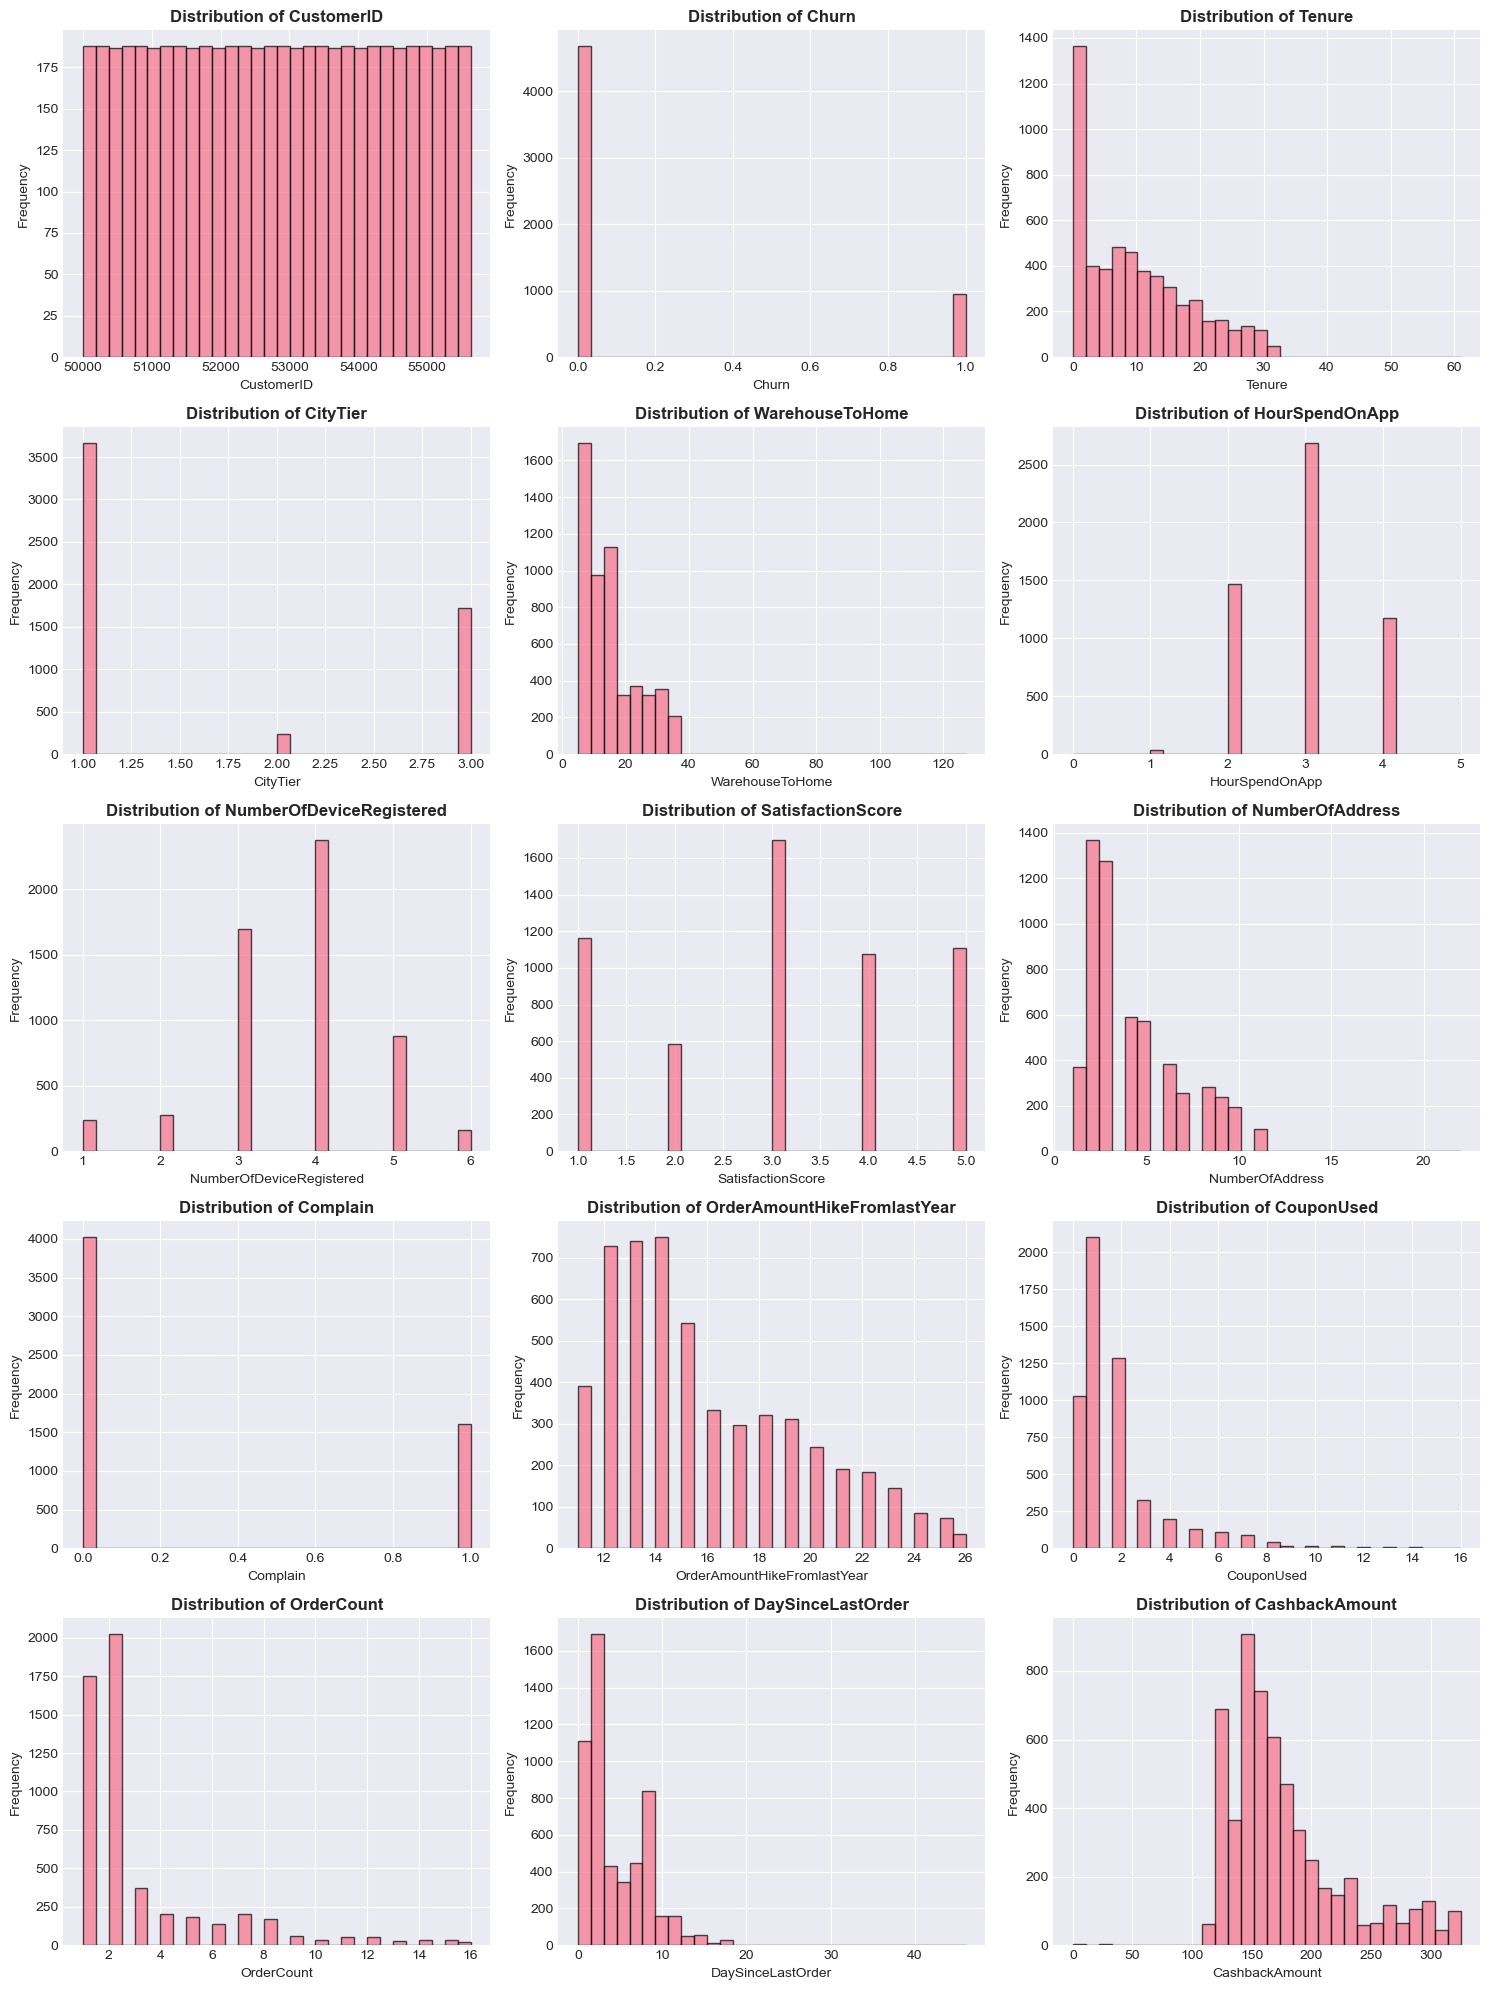

In [38]:
# Analyze numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("="*80)
print("NUMERICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Numerical columns: {numerical_cols}\n")

if len(numerical_cols) > 0:
    # Plot distributions
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [39]:
# Analyze categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Categorical columns: {categorical_cols}\n")

for col in categorical_cols:
    if df[col].nunique() < 50:  # Only show for columns with fewer categories
        print(f"\n{col} - Value Counts:")
        print(df[col].value_counts().head(10))
        print(f"Unique values: {df[col].nunique()}")

CATEGORICAL COLUMNS ANALYSIS
Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


PreferredLoginDevice - Value Counts:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
Unique values: 3

PreferredPaymentMode - Value Counts:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Unique values: 7

Gender - Value Counts:
Gender
Male      3384
Female    2246
Name: count, dtype: int64
Unique values: 2

PreferedOrderCat - Value Counts:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
Unique values: 6

MaritalStatus - Value Counts:
MaritalStatus
Marrie

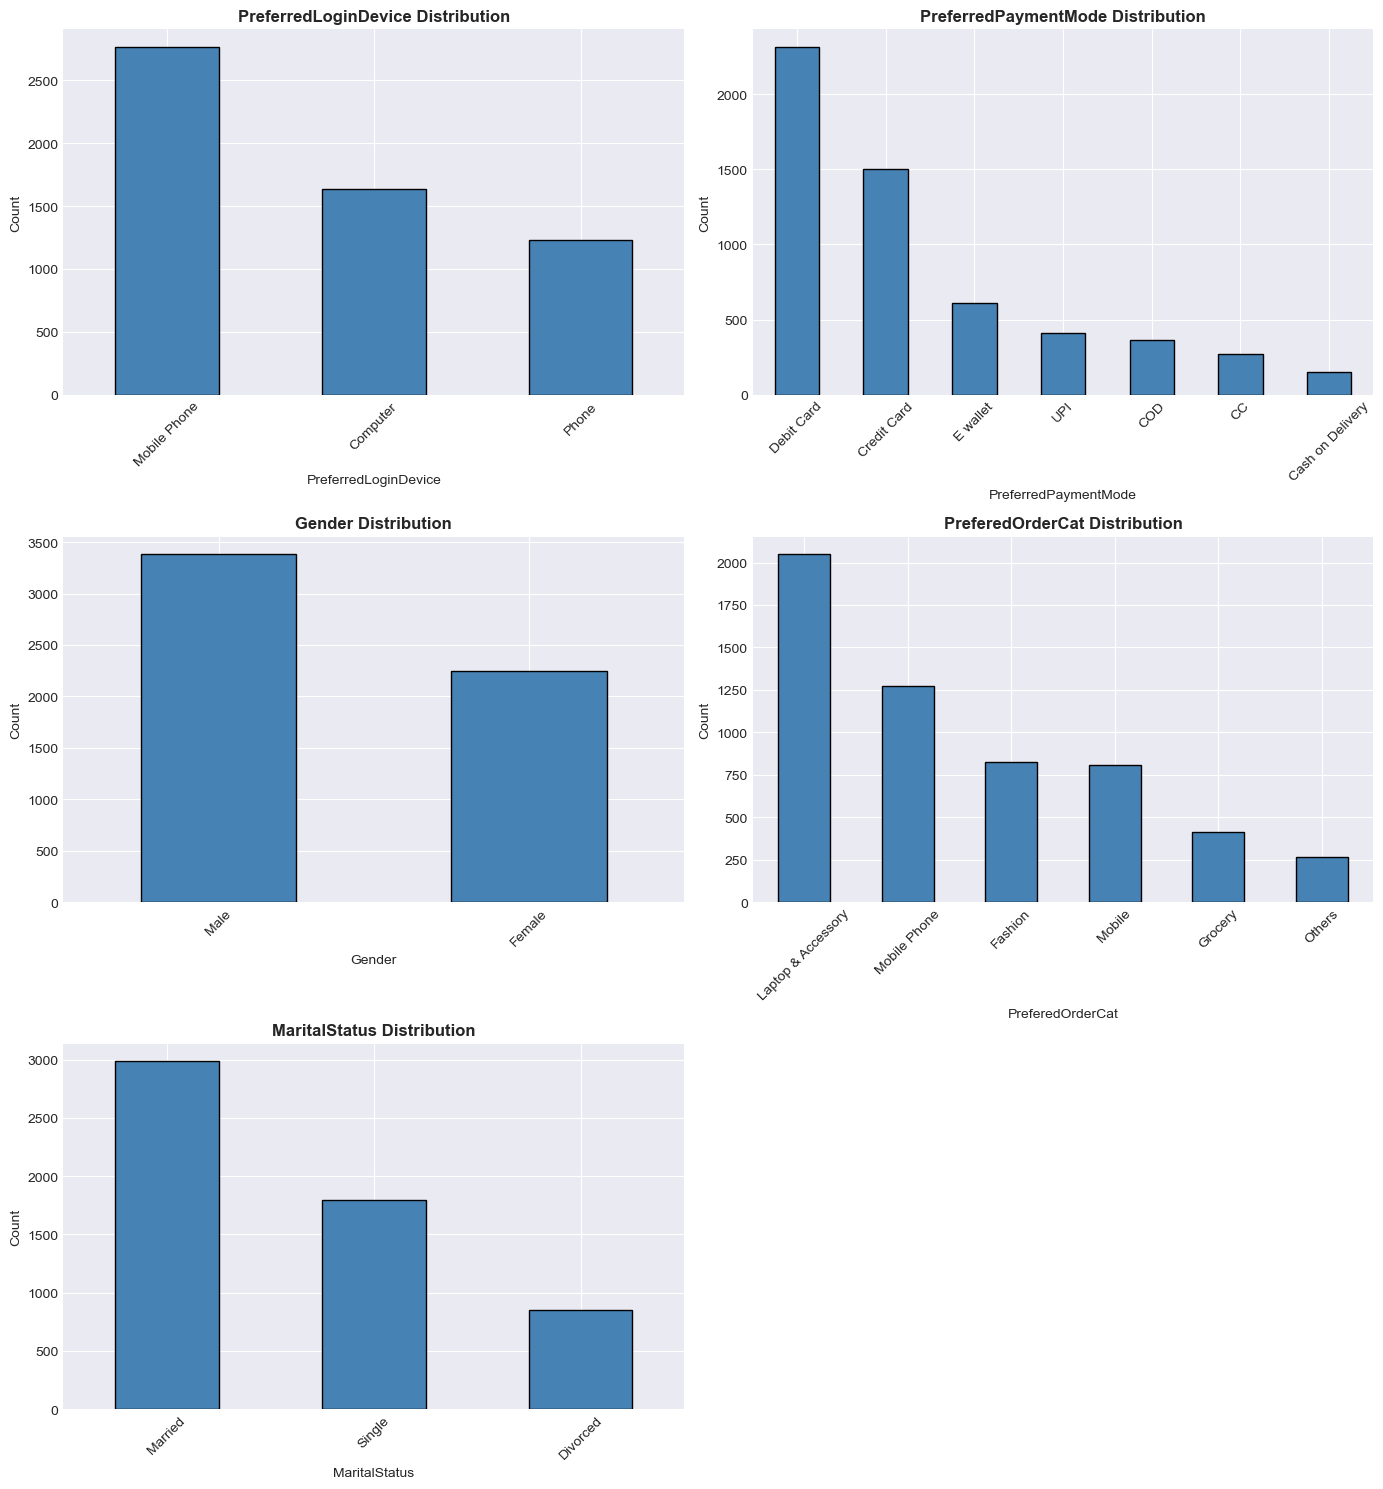

In [40]:
# Visualize top categorical variables
categorical_to_plot = [col for col in categorical_cols if df[col].nunique() < 15]

if len(categorical_to_plot) > 0:
    n_cols = min(2, len(categorical_to_plot))
    n_rows = (len(categorical_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if len(categorical_to_plot) > 1 else [axes]
    
    for idx, col in enumerate(categorical_to_plot):
        if idx < len(axes):
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
            axes[idx].set_title(f'{col} Distribution', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplots
    for idx in range(len(categorical_to_plot), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Bivariate Analysis

CORRELATION ANALYSIS


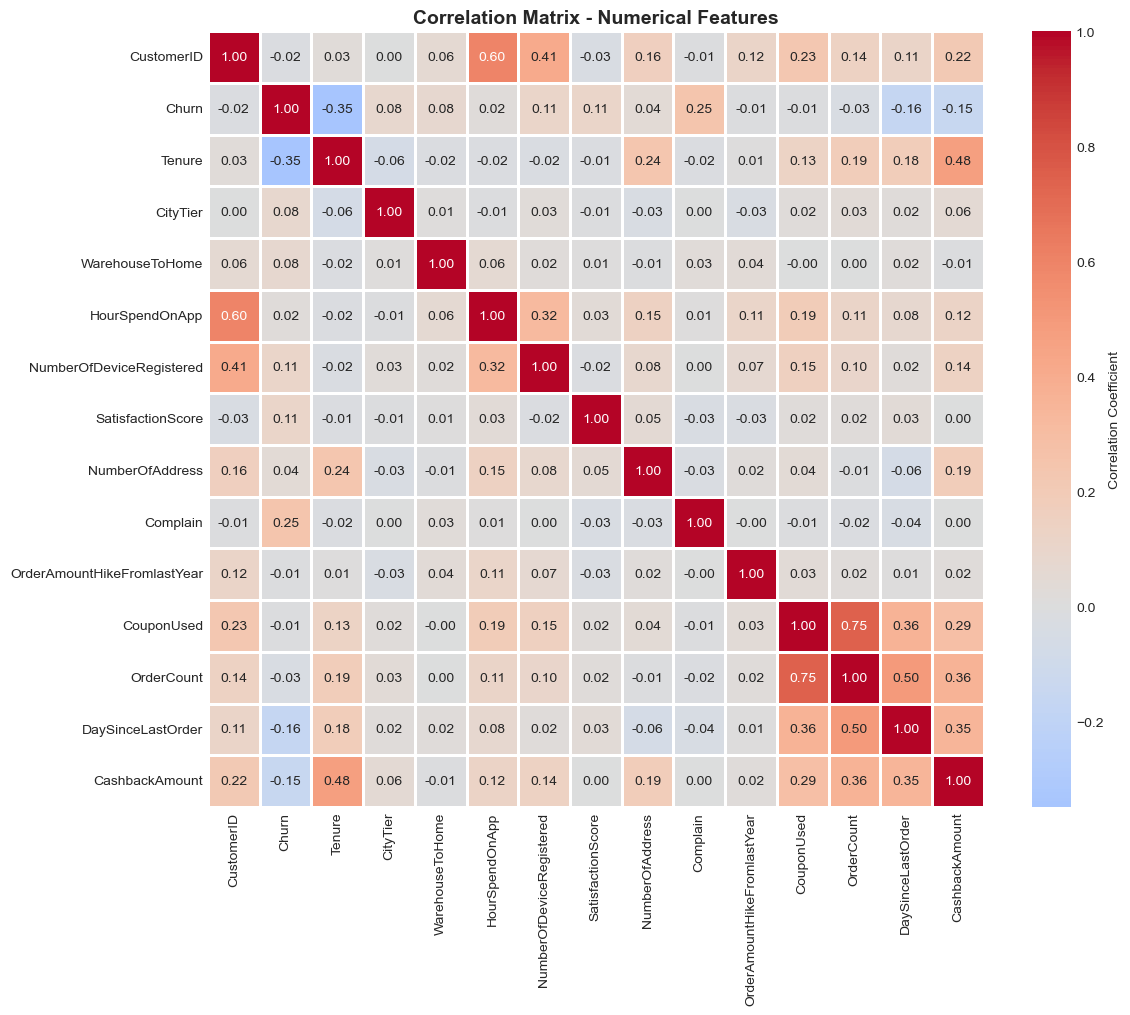


Strong Correlations (|r| > 0.5):
  CustomerID ↔ HourSpendOnApp: 0.598
  CouponUsed ↔ OrderCount: 0.745


In [41]:
# Correlation matrix for numerical variables
if len(numerical_cols) > 1:
    print("="*80)
    print("CORRELATION ANALYSIS")
    print("="*80)
    
    correlation_matrix = df[numerical_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm', 
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                print(f"  {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

## 7. Customer Analysis (if customer ID exists)

 Customer ID column identified: CustomerID

Total unique customers: 5,630
Total transactions: 5,630
Average transactions per customer: 1.00


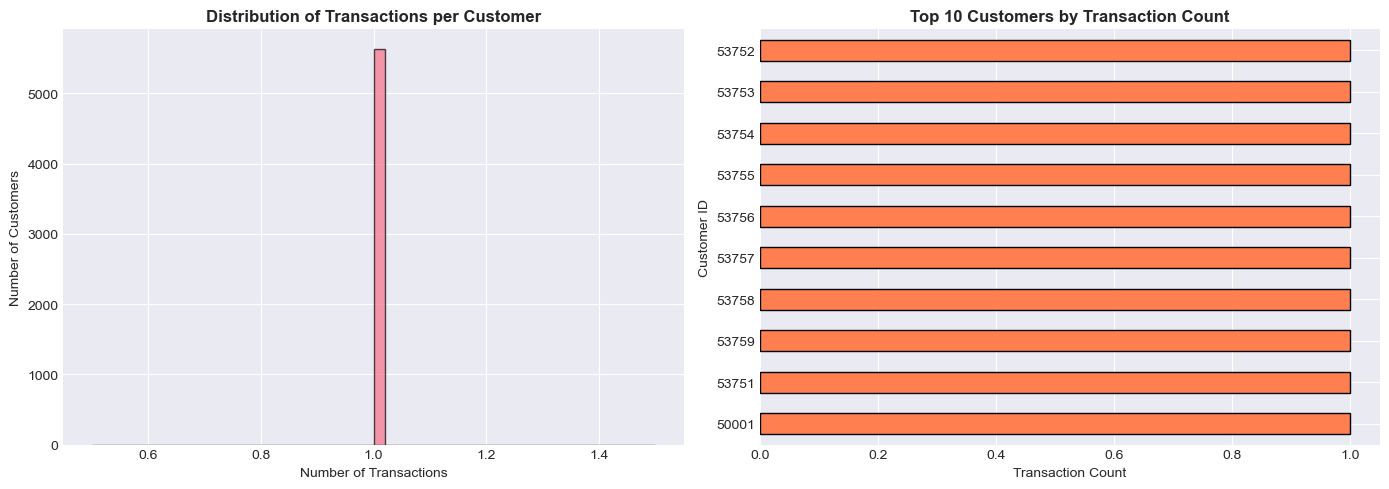

In [42]:
# Try to identify customer ID column
customer_col = None
possible_customer_cols = ['customer_id', 'customerid', 'cust_id', 'user_id', 'userid', 'member_id', 'memberid']

for col in df.columns:
    if col.lower() in possible_customer_cols:
        customer_col = col
        break

if customer_col:
    print(f" Customer ID column identified: {customer_col}")
    print(f"\nTotal unique customers: {df[customer_col].nunique():,}")
    print(f"Total transactions: {len(df):,}")
    print(f"Average transactions per customer: {len(df)/df[customer_col].nunique():.2f}")
    
    # Customer frequency distribution
    customer_freq = df[customer_col].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of transactions per customer
    customer_freq.hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Transactions per Customer', fontweight='bold')
    axes[0].set_xlabel('Number of Transactions')
    axes[0].set_ylabel('Number of Customers')
    
    # Top customers
    customer_freq.head(10).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Top 10 Customers by Transaction Count', fontweight='bold')
    axes[1].set_xlabel('Transaction Count')
    axes[1].set_ylabel('Customer ID')
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ No customer ID column detected")
    print(f"Available columns: {df.columns.tolist()}")

## 8. Temporal Analysis (if date columns exist)

In [43]:
# Analyze temporal patterns
if len(date_columns) > 0:
    for date_col in date_columns:
        if df[date_col].dtype == 'datetime64[ns]':
            print(f"\n{'='*80}")
            print(f"TEMPORAL ANALYSIS - {date_col}")
            print(f"{'='*80}")
            
            # Date range
            print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
            print(f"Total days: {(df[date_col].max() - df[date_col].min()).days} days")
            
            # Extract time features
            df[f'{date_col}_year'] = df[date_col].dt.year
            df[f'{date_col}_month'] = df[date_col].dt.month
            df[f'{date_col}_day'] = df[date_col].dt.day
            df[f'{date_col}_dayofweek'] = df[date_col].dt.dayofweek
            df[f'{date_col}_hour'] = df[date_col].dt.hour
            
            # Plot trends
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Trend over time
            df.groupby(df[date_col].dt.date).size().plot(ax=axes[0,0], color='steelblue')
            axes[0,0].set_title(f'Daily Transactions - {date_col}', fontweight='bold')
            axes[0,0].set_xlabel('Date')
            axes[0,0].set_ylabel('Transaction Count')
            axes[0,0].tick_params(axis='x', rotation=45)
            
            # By month
            df[f'{date_col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
            axes[0,1].set_title('Transactions by Month', fontweight='bold')
            axes[0,1].set_xlabel('Month')
            axes[0,1].set_ylabel('Count')
            
            # By day of week
            day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
            day_counts = df[f'{date_col}_dayofweek'].value_counts().sort_index()
            day_counts.index = [day_names[i] for i in day_counts.index]
            day_counts.plot(kind='bar', ax=axes[1,0], color='lightgreen', edgecolor='black')
            axes[1,0].set_title('Transactions by Day of Week', fontweight='bold')
            axes[1,0].set_xlabel('Day')
            axes[1,0].set_ylabel('Count')
            
            # By hour (if available)
            if df[f'{date_col}_hour'].notna().sum() > 0:
                df[f'{date_col}_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='plum', edgecolor='black')
                axes[1,1].set_title('Transactions by Hour', fontweight='bold')
                axes[1,1].set_xlabel('Hour')
                axes[1,1].set_ylabel('Count')
            else:
                axes[1,1].text(0.5, 0.5, 'No hourly data available', 
                              ha='center', va='center', transform=axes[1,1].transAxes)
                axes[1,1].axis('off')
            
            plt.tight_layout()
            plt.show()
else:
    print(" No date columns detected for temporal analysis")

 No date columns detected for temporal analysis


## 9. Outlier Detection

OUTLIER DETECTION (IQR Method)
                         Column  Outlier_Count  Outlier_Percentage  \
1                         Churn            948               16.84   
12                   OrderCount            703               12.49   
11                   CouponUsed            629               11.17   
14               CashbackAmount            438                7.78   
6      NumberOfDeviceRegistered            397                7.05   
13            DaySinceLastOrder             62                1.10   
10  OrderAmountHikeFromlastYear             33                0.59   
5                HourSpendOnApp              6                0.11   
2                        Tenure              4                0.07   
8               NumberOfAddress              4                0.07   
4               WarehouseToHome              2                0.04   
0                    CustomerID              0                0.00   
3                      CityTier              0             

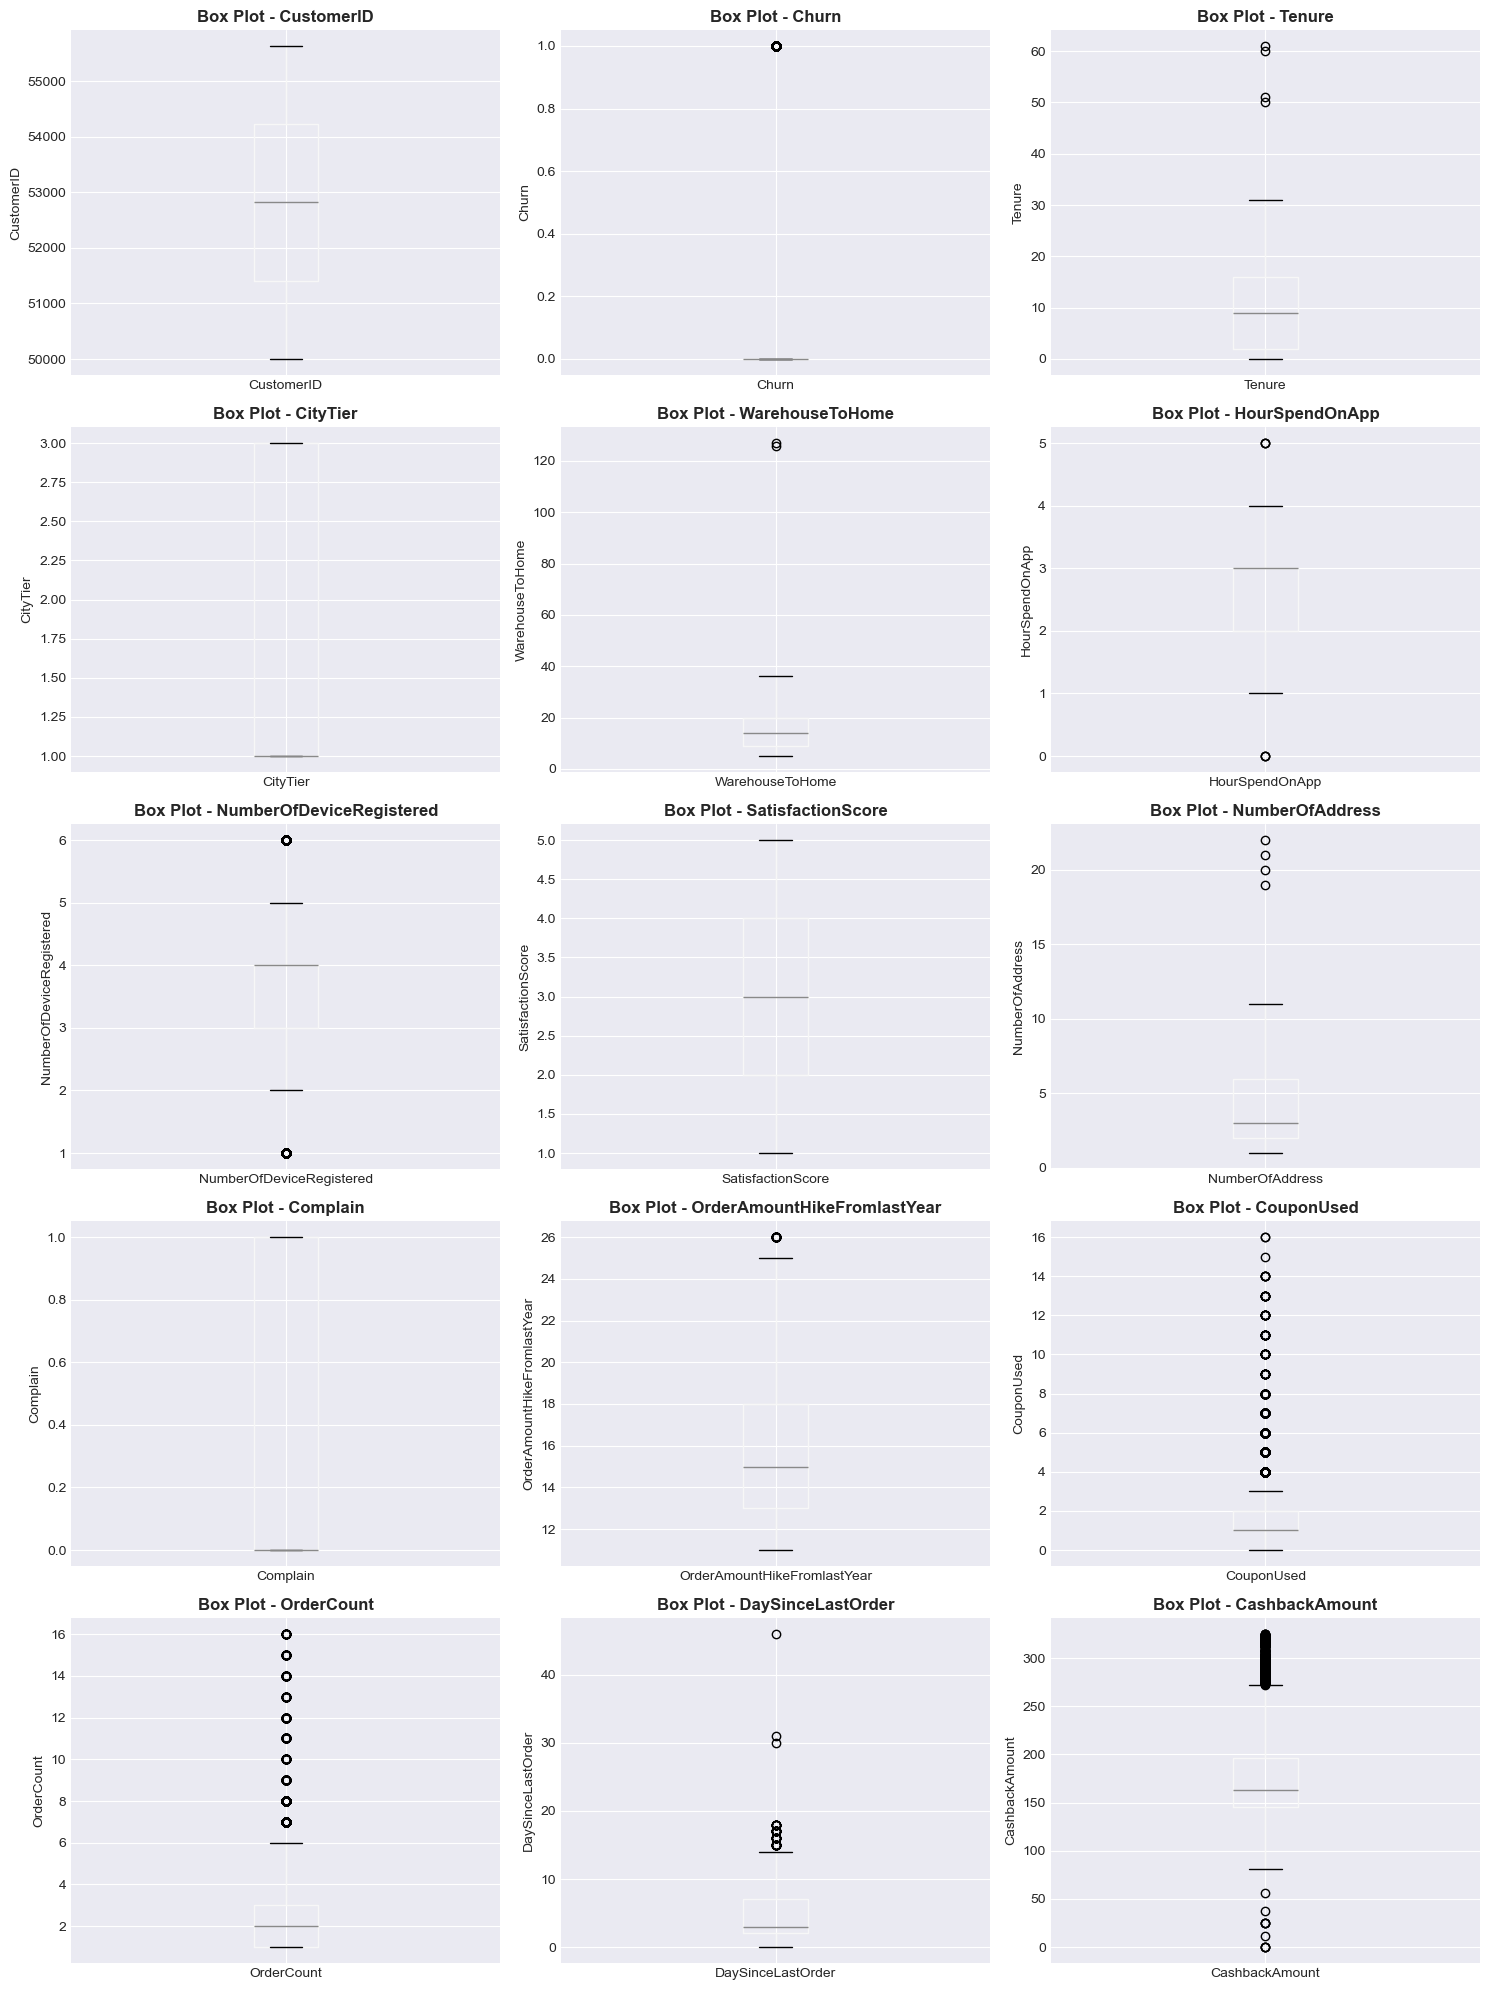

In [44]:
# Detect outliers using IQR method
if len(numerical_cols) > 0:
    print("="*80)
    print("OUTLIER DETECTION (IQR Method)")
    print("="*80)
    
    outlier_summary = []
    
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
    print(outlier_df)
    
    # Box plots for outlier visualization
    if len(numerical_cols) > 0:
        n_cols = min(3, len(numerical_cols))
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
        
        for idx, col in enumerate(numerical_cols):
            if idx < len(axes):
                df.boxplot(column=col, ax=axes[idx])
                axes[idx].set_title(f'Box Plot - {col}', fontweight='bold')
                axes[idx].set_ylabel(col)
        
        # Hide extra subplots
        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

## 10. Key Insights & Summary

In [45]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)

print(f"\n DATASET OVERVIEW:")
print(f"  • Total Records: {len(df):,}")
print(f"  • Total Features: {df.shape[1]}")
print(f"  • Numerical Features: {len(numerical_cols)}")
print(f"  • Categorical Features: {len(categorical_cols)}")
print(f"  • Date Features: {len(date_columns)}")

if customer_col:
    print(f"\n CUSTOMER METRICS:")
    print(f"  • Unique Customers: {df[customer_col].nunique():,}")
    print(f"  • Avg Transactions per Customer: {len(df)/df[customer_col].nunique():.2f}")

print(f"\n DATA QUALITY:")
total_missing = df.isnull().sum().sum()
completeness = (1 - total_missing/(df.shape[0]*df.shape[1]))*100
print(f"  • Missing Values: {total_missing:,}")
print(f"  • Data Completeness: {completeness:.2f}%")
print(f"  • Duplicate Rows: {df.duplicated().sum():,}")

if len(numerical_cols) > 0:
    print(f"\n NUMERICAL FEATURES:")
    for col in numerical_cols[:5]:  # Show first 5
        print(f"  • {col}:")
        print(f"      - Mean: {df[col].mean():.2f}")
        print(f"      - Median: {df[col].median():.2f}")
        print(f"      - Std Dev: {df[col].std():.2f}")

print(f"\n EDA COMPLETED SUCCESSFULLY!")
print(f"\nNext steps:")
print(f"  1. Feature engineering based on insights")
print(f"  2. Handle missing values and outliers")
print(f"  3. Prepare data for modeling")
print(f"  4. Build predictive models")

EXPLORATORY DATA ANALYSIS SUMMARY

 DATASET OVERVIEW:
  • Total Records: 5,630
  • Total Features: 20
  • Numerical Features: 15
  • Categorical Features: 5
  • Date Features: 0

 CUSTOMER METRICS:
  • Unique Customers: 5,630
  • Avg Transactions per Customer: 1.00

 DATA QUALITY:
  • Missing Values: 1,856
  • Data Completeness: 98.35%
  • Duplicate Rows: 0

 NUMERICAL FEATURES:
  • CustomerID:
      - Mean: 52815.50
      - Median: 52815.50
      - Std Dev: 1625.39
  • Churn:
      - Mean: 0.17
      - Median: 0.00
      - Std Dev: 0.37
  • Tenure:
      - Mean: 10.19
      - Median: 9.00
      - Std Dev: 8.56
  • CityTier:
      - Mean: 1.65
      - Median: 1.00
      - Std Dev: 0.92
  • WarehouseToHome:
      - Mean: 15.64
      - Median: 14.00
      - Std Dev: 8.53

 EDA COMPLETED SUCCESSFULLY!

Next steps:
  1. Feature engineering based on insights
  2. Handle missing values and outliers
  3. Prepare data for modeling
  4. Build predictive models


## 12. Feature Engineering for Machine Learning

Creating advanced features to improve model performance and capture complex patterns in customer behavior.

In [46]:
# Create a copy for feature engineering
df_ml = df.copy()

print("="*80)
print("FEATURE ENGINEERING - PART 1: TENURE & LIFECYCLE")
print("="*80)

# 1. TENURE-BASED FEATURES
# Fill missing tenure with median
df_ml['Tenure'].fillna(df_ml['Tenure'].median(), inplace=True)

# Tenure segments
df_ml['Tenure_Segment'] = pd.cut(df_ml['Tenure'], 
                                  bins=[-1, 3, 6, 12, 24, 100],
                                  labels=['New (0-3m)', 'Growing (3-6m)', 'Established (6-12m)', 
                                         'Loyal (12-24m)', 'Champion (24m+)'])

# Is new customer (first 3 months)
df_ml['Is_New_Customer'] = (df_ml['Tenure'] <= 3).astype(int)

# Is loyal customer (>12 months)
df_ml['Is_Loyal_Customer'] = (df_ml['Tenure'] > 12).astype(int)

# Tenure in years
df_ml['Tenure_Years'] = df_ml['Tenure'] / 12

print(f" Tenure features created:")
print(f"   - Tenure_Segment (5 categories)")
print(f"   - Is_New_Customer (binary)")
print(f"   - Is_Loyal_Customer (binary)")
print(f"   - Tenure_Years (continuous)")
print(f"\nTenure Segment Distribution:")
print(df_ml['Tenure_Segment'].value_counts().sort_index())

FEATURE ENGINEERING - PART 1: TENURE & LIFECYCLE
 Tenure features created:
   - Tenure_Segment (5 categories)
   - Is_New_Customer (binary)
   - Is_Loyal_Customer (binary)
   - Tenure_Years (continuous)

Tenure Segment Distribution:
Tenure_Segment
New (0-3m)             1560
Growing (3-6m)          590
Established (6-12m)    1584
Loyal (12-24m)         1467
Champion (24m+)         429
Name: count, dtype: int64


In [47]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 2: ENGAGEMENT & ACTIVITY")
print("="*80)

# 2. ENGAGEMENT FEATURES
# Fill missing HourSpendOnApp
df_ml['HourSpendOnApp'].fillna(df_ml['HourSpendOnApp'].median(), inplace=True)

# Engagement score (normalized combination of app usage and order activity)
df_ml['Engagement_Score'] = (
    (df_ml['HourSpendOnApp'] / df_ml['HourSpendOnApp'].max() * 0.4) +
    (df_ml['OrderCount'] / df_ml['OrderCount'].max() * 0.3) +
    ((df_ml['DaySinceLastOrder'].max() - df_ml['DaySinceLastOrder']) / df_ml['DaySinceLastOrder'].max() * 0.3)
)

# App usage categories
df_ml['App_Usage_Level'] = pd.cut(df_ml['HourSpendOnApp'],
                                   bins=[-1, 1, 2, 3, 100],
                                   labels=['Low', 'Medium', 'High', 'Very High'])

# Is highly engaged (top 25% engagement score)
engagement_threshold = df_ml['Engagement_Score'].quantile(0.75)
df_ml['Is_Highly_Engaged'] = (df_ml['Engagement_Score'] >= engagement_threshold).astype(int)

# Device engagement (more devices = more engaged)
df_ml['Is_Multi_Device_User'] = (df_ml['NumberOfDeviceRegistered'] >= 4).astype(int)

print(f" Engagement features created:")
print(f"   - Engagement_Score (0-1 scale)")
print(f"   - App_Usage_Level (4 categories)")
print(f"   - Is_Highly_Engaged (binary)")
print(f"   - Is_Multi_Device_User (binary)")
print(f"\nEngagement Score Statistics:")
print(df_ml['Engagement_Score'].describe())


FEATURE ENGINEERING - PART 2: ENGAGEMENT & ACTIVITY
 Engagement features created:
   - Engagement_Score (0-1 scale)
   - App_Usage_Level (4 categories)
   - Is_Highly_Engaged (binary)
   - Is_Multi_Device_User (binary)

Engagement Score Statistics:
count   5,065.00
mean        0.56
std         0.08
min         0.30
25%         0.51
50%         0.56
75%         0.61
max         0.90
Name: Engagement_Score, dtype: float64


In [48]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 3: RFM SCORING")
print("="*80)

# 3. RFM FEATURES
# Recency Score (inverse - lower days since last order = higher score)
try:
    df_ml['Recency_Score'] = pd.qcut(df_ml['DaySinceLastOrder'], q=5, duplicates='drop')
    # Create reverse mapping: lowest recency (most recent) = highest score
    recency_mapping = {cat: 5-i for i, cat in enumerate(df_ml['Recency_Score'].cat.categories)}
    df_ml['Recency_Score'] = df_ml['Recency_Score'].map(recency_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Recency_Score'] = pd.cut(df_ml['DaySinceLastOrder'], bins=5, labels=[5,4,3,2,1]).fillna(3).astype(int)

# Frequency Score (order count)
try:
    df_ml['Frequency_Score'] = pd.qcut(df_ml['OrderCount'], q=5, duplicates='drop')
    # Create mapping: higher frequency = higher score
    freq_mapping = {cat: i+1 for i, cat in enumerate(df_ml['Frequency_Score'].cat.categories)}
    df_ml['Frequency_Score'] = df_ml['Frequency_Score'].map(freq_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Frequency_Score'] = pd.cut(df_ml['OrderCount'], bins=5, labels=[1,2,3,4,5]).fillna(3).astype(int)

# Monetary Score (order amount cat as proxy)
try:
    df_ml['Monetary_Score'] = pd.qcut(df_ml['OrderAmountHikeFromlastYear'], q=5, duplicates='drop')
    # Create mapping: higher monetary value = higher score
    monetary_mapping = {cat: i+1 for i, cat in enumerate(df_ml['Monetary_Score'].cat.categories)}
    df_ml['Monetary_Score'] = df_ml['Monetary_Score'].map(monetary_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Monetary_Score'] = pd.cut(df_ml['OrderAmountHikeFromlastYear'], bins=5, labels=[1,2,3,4,5]).fillna(3).astype(int)

# Combined RFM Score
df_ml['RFM_Score'] = (df_ml['Recency_Score'] * 100 + 
                      df_ml['Frequency_Score'] * 10 + 
                      df_ml['Monetary_Score'])

# RFM Segments
def rfm_segment(row):
    if row['RFM_Score'] >= 444:
        return 'Champions'
    elif row['RFM_Score'] >= 344:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 334:
        return 'Potential Loyalist'
    elif row['RFM_Score'] >= 244:
        return 'Recent Customers'
    elif row['RFM_Score'] >= 234:
        return 'Promising'
    elif row['RFM_Score'] >= 144:
        return 'Need Attention'
    elif row['RFM_Score'] >= 134:
        return 'About to Sleep'
    else:
        return 'At Risk'

df_ml['RFM_Segment'] = df_ml.apply(rfm_segment, axis=1)

print(f" RFM features created:")
print(f"   - Recency_Score (1-5)")
print(f"   - Frequency_Score (1-5)")
print(f"   - Monetary_Score (1-5)")
print(f"   - RFM_Score (111-555)")
print(f"   - RFM_Segment (8 categories)")
print(f"\nRFM Segment Distribution:")
print(df_ml['RFM_Segment'].value_counts())


FEATURE ENGINEERING - PART 3: RFM SCORING
 RFM features created:
   - Recency_Score (1-5)
   - Frequency_Score (1-5)
   - Monetary_Score (1-5)
   - RFM_Score (111-555)
   - RFM_Segment (8 categories)

RFM Segment Distribution:
RFM_Segment
Loyal Customers       1692
Need Attention        1159
Champions             1110
Recent Customers       682
At Risk                648
Promising              167
About to Sleep         116
Potential Loyalist      56
Name: count, dtype: int64
 RFM features created:
   - Recency_Score (1-5)
   - Frequency_Score (1-5)
   - Monetary_Score (1-5)
   - RFM_Score (111-555)
   - RFM_Segment (8 categories)

RFM Segment Distribution:
RFM_Segment
Loyal Customers       1692
Need Attention        1159
Champions             1110
Recent Customers       682
At Risk                648
Promising              167
About to Sleep         116
Potential Loyalist      56
Name: count, dtype: int64


In [49]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 4: INTERACTION & BEHAVIORAL FEATURES")
print("="*80)

# 4. INTERACTION FEATURES
# Satisfaction-Complaint interaction
df_ml['Sat_Complain_Interaction'] = df_ml['SatisfactionScore'] * (1 - df_ml['Complain'])

# High satisfaction but complained (conflicting behavior)
df_ml['Conflicting_Feedback'] = ((df_ml['SatisfactionScore'] >= 4) & (df_ml['Complain'] == 1)).astype(int)

# Low satisfaction but no complaint (silent dissatisfaction)
df_ml['Silent_Dissatisfaction'] = ((df_ml['SatisfactionScore'] <= 2) & (df_ml['Complain'] == 0)).astype(int)

# Order frequency ratio (orders per month of tenure)
df_ml['Order_Frequency_Ratio'] = df_ml['OrderCount'] / (df_ml['Tenure'] + 1)  # +1 to avoid division by zero

# Discount dependency
df_ml['Discount_Dependency'] = df_ml['CouponUsed'] / (df_ml['OrderCount'] + 1)

# Cashback engagement
df_ml['Cashback_Per_Order'] = df_ml['CashbackAmount'] / (df_ml['OrderCount'] + 1)

# Recent activity flag
df_ml['Is_Recently_Active'] = (df_ml['DaySinceLastOrder'] <= 7).astype(int)
df_ml['Is_Dormant'] = (df_ml['DaySinceLastOrder'] > 60).astype(int)

print(f" Interaction & behavioral features created:")
print(f"   - Sat_Complain_Interaction (continuous)")
print(f"   - Conflicting_Feedback (binary)")
print(f"   - Silent_Dissatisfaction (binary)")
print(f"   - Order_Frequency_Ratio (orders per month)")
print(f"   - Discount_Dependency (0-1 ratio)")
print(f"   - Cashback_Per_Order (average cashback)")
print(f"   - Is_Recently_Active (binary)")
print(f"   - Is_Dormant (binary)")
print(f"\nKey Statistics:")
print(f"Order Frequency Ratio: {df_ml['Order_Frequency_Ratio'].mean():.3f} orders/month")
print(f"Discount Dependency: {df_ml['Discount_Dependency'].mean():.2%}")
print(f"Recently Active Customers: {df_ml['Is_Recently_Active'].sum():,} ({df_ml['Is_Recently_Active'].mean():.1%})")
print(f"Dormant Customers: {df_ml['Is_Dormant'].sum():,} ({df_ml['Is_Dormant'].mean():.1%})")


FEATURE ENGINEERING - PART 4: INTERACTION & BEHAVIORAL FEATURES
 Interaction & behavioral features created:
   - Sat_Complain_Interaction (continuous)
   - Conflicting_Feedback (binary)
   - Silent_Dissatisfaction (binary)
   - Order_Frequency_Ratio (orders per month)
   - Discount_Dependency (0-1 ratio)
   - Cashback_Per_Order (average cashback)
   - Is_Recently_Active (binary)
   - Is_Dormant (binary)

Key Statistics:
Order Frequency Ratio: 0.588 orders/month
Discount Dependency: 40.55%
Recently Active Customers: 4,021 (71.4%)
Dormant Customers: 0 (0.0%)


In [50]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 5: CUSTOMER VALUE & RISK FEATURES")
print("="*80)

# 5. CUSTOMER VALUE & RISK FEATURES
# Customer Lifetime Value proxy (combining tenure, orders, and spending growth)
df_ml['CLV_Proxy'] = (
    df_ml['Tenure'] * 0.3 +
    df_ml['OrderCount'] * 0.4 +
    df_ml['OrderAmountHikeFromlastYear'] * 0.3
)

# Normalize to 0-100 scale
df_ml['CLV_Score'] = (df_ml['CLV_Proxy'] - df_ml['CLV_Proxy'].min()) / (df_ml['CLV_Proxy'].max() - df_ml['CLV_Proxy'].min()) * 100

# High-value customer flag
clv_threshold = df_ml['CLV_Score'].quantile(0.75)
df_ml['Is_High_Value_Customer'] = (df_ml['CLV_Score'] >= clv_threshold).astype(int)

# Churn risk score (combining negative indicators)
df_ml['Churn_Risk_Score'] = (
    (df_ml['DaySinceLastOrder'] / df_ml['DaySinceLastOrder'].max() * 0.25) +
    (1 - df_ml['SatisfactionScore'] / 5 * 0.20) +
    (df_ml['Complain'] * 0.20) +
    (1 - df_ml['Engagement_Score'] * 0.20) +
    ((df_ml['Tenure'].max() - df_ml['Tenure']) / df_ml['Tenure'].max() * 0.15)
)

# Risk segments
df_ml['Risk_Segment'] = pd.cut(df_ml['Churn_Risk_Score'],
                                bins=[-0.01, 0.3, 0.5, 0.7, 1.01],
                                labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'])

# Payment behavior
df_ml['Uses_Credit_Card'] = (df_ml['PreferredPaymentMode'] == 'Credit Card').astype(int)
df_ml['Uses_Cash_On_Delivery'] = (df_ml['PreferredPaymentMode'] == 'Cash on Delivery').astype(int)
df_ml['Uses_Digital_Payment'] = df_ml['PreferredPaymentMode'].isin(['Debit Card', 'UPI', 'E wallet']).astype(int)

# Order amount trend flag
df_ml['Increasing_Spend'] = (df_ml['OrderAmountHikeFromlastYear'] > 15).astype(int)
df_ml['Decreasing_Spend'] = (df_ml['OrderAmountHikeFromlastYear'] < 11).astype(int)

print(f" Customer value & risk features created:")
print(f"   - CLV_Score (0-100)")
print(f"   - Is_High_Value_Customer (binary)")
print(f"   - Churn_Risk_Score (0-1)")
print(f"   - Risk_Segment (4 categories)")
print(f"   - Payment behavior flags (3 binary)")
print(f"   - Spend trend flags (2 binary)")
print(f"\nRisk Segment Distribution:")
print(df_ml['Risk_Segment'].value_counts())
print(f"\nHigh Value Customers: {df_ml['Is_High_Value_Customer'].sum():,} ({df_ml['Is_High_Value_Customer'].mean():.1%})")


FEATURE ENGINEERING - PART 5: CUSTOMER VALUE & RISK FEATURES
 Customer value & risk features created:
   - CLV_Score (0-100)
   - Is_High_Value_Customer (binary)
   - Churn_Risk_Score (0-1)
   - Risk_Segment (4 categories)
   - Payment behavior flags (3 binary)
   - Spend trend flags (2 binary)

Risk Segment Distribution:
Risk_Segment
Low Risk         0
Medium Risk      0
High Risk        0
Critical Risk    0
Name: count, dtype: int64

High Value Customers: 1,324 (23.5%)


In [51]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 6: DEMOGRAPHIC & PREFERENCE FEATURES")
print("="*80)

# 6. DEMOGRAPHIC & PREFERENCE FEATURES
# Marital status encoding
df_ml['Is_Married'] = (df_ml['MaritalStatus'] == 'Married').astype(int)
df_ml['Is_Single'] = (df_ml['MaritalStatus'] == 'Single').astype(int)

# Address distance categories
df_ml['Address_Distance_Category'] = pd.cut(df_ml['WarehouseToHome'],
                                              bins=[-1, 10, 20, 30, 200],
                                              labels=['Very Close', 'Close', 'Moderate', 'Far'])

# Is address nearby (within 10 km)
df_ml['Is_Address_Nearby'] = (df_ml['WarehouseToHome'] <= 10).astype(int)

# Device preference
df_ml['Prefers_Mobile'] = (df_ml['PreferedOrderCat'] == 'Mobile Phone').astype(int)
df_ml['Prefers_Laptop'] = (df_ml['PreferedOrderCat'] == 'Laptop & Accessory').astype(int)
df_ml['Prefers_Fashion'] = (df_ml['PreferedOrderCat'] == 'Fashion').astype(int)

# City tier encoding
df_ml['Is_Tier1_City'] = (df_ml['CityTier'] == 1).astype(int)
df_ml['Is_Tier3_City'] = (df_ml['CityTier'] == 3).astype(int)

# Gender encoding (if needed for some models)
df_ml['Is_Male'] = (df_ml['Gender'] == 'Male').astype(int)
df_ml['Is_Female'] = (df_ml['Gender'] == 'Female').astype(int)

# Login device count categories
df_ml['Device_Usage_Level'] = pd.cut(df_ml['NumberOfDeviceRegistered'],
                                       bins=[-1, 2, 4, 6, 10],
                                       labels=['Low', 'Medium', 'High', 'Very High'])

print(f" Demographic & preference features created:")
print(f"   - Marital status flags (2 binary)")
print(f"   - Address_Distance_Category (4 categories)")
print(f"   - Is_Address_Nearby (binary)")
print(f"   - Product preference flags (3 binary)")
print(f"   - City tier flags (2 binary)")
print(f"   - Gender flags (2 binary)")
print(f"   - Device_Usage_Level (4 categories)")
print(f"\nPreferred Product Categories:")
print(df_ml['PreferedOrderCat'].value_counts().head())
print(f"\nCity Tier Distribution:")
print(df_ml['CityTier'].value_counts())


FEATURE ENGINEERING - PART 6: DEMOGRAPHIC & PREFERENCE FEATURES
 Demographic & preference features created:
   - Marital status flags (2 binary)
   - Address_Distance_Category (4 categories)
   - Is_Address_Nearby (binary)
   - Product preference flags (3 binary)
   - City tier flags (2 binary)
   - Gender flags (2 binary)
   - Device_Usage_Level (4 categories)

Preferred Product Categories:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Name: count, dtype: int64

City Tier Distribution:
CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64
 Demographic & preference features created:
   - Marital status flags (2 binary)
   - Address_Distance_Category (4 categories)
   - Is_Address_Nearby (binary)
   - Product preference flags (3 binary)
   - City tier flags (2 binary)
   - Gender flags (2 binary)
   - Device_Usage_Level (4 categories)

Preferred Product Categories:
Prefe

In [52]:
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

# Count features by category
original_features = 20
tenure_features = 4
engagement_features = 4
rfm_features = 5
interaction_features = 8
value_risk_features = 9
demographic_features = 12

total_engineered = (tenure_features + engagement_features + rfm_features + 
                   interaction_features + value_risk_features + demographic_features)

print(f"\n Feature Count Summary:")
print(f"   Original Features: {original_features}")
print(f"   ├─ Tenure Features: +{tenure_features}")
print(f"   ├─ Engagement Features: +{engagement_features}")
print(f"   ├─ RFM Features: +{rfm_features}")
print(f"   ├─ Interaction Features: +{interaction_features}")
print(f"   ├─ Value & Risk Features: +{value_risk_features}")
print(f"   └─ Demographic Features: +{demographic_features}")
print(f"   " + "─"*50)
print(f"   Total Engineered Features: {total_engineered}")
print(f"   Total Features in Dataset: {df_ml.shape[1]}")

print(f"\n Dataset Shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")

print(f"\n Key Engineered Features for ML:")
key_features = [
    'Engagement_Score', 'RFM_Score', 'CLV_Score', 'Churn_Risk_Score',
    'Order_Frequency_Ratio', 'Discount_Dependency', 'Tenure_Years',
    'Is_High_Value_Customer', 'Is_Highly_Engaged', 'Is_Dormant'
]
for feat in key_features:
    if feat in df_ml.columns:
        print(f"   ✓ {feat}")

print(f"\n Ready for Machine Learning:")

# Display sample of engineered features
print(f"\n Sample of Engineered Features:")
sample_cols = ['CustomerID', 'Churn', 'Engagement_Score', 'RFM_Score', 'CLV_Score', 
               'Churn_Risk_Score', 'Risk_Segment', 'RFM_Segment']
display_cols = [col for col in sample_cols if col in df_ml.columns]
print(df_ml[display_cols].head(10))


FEATURE ENGINEERING SUMMARY

 Feature Count Summary:
   Original Features: 20
   ├─ Tenure Features: +4
   ├─ Engagement Features: +4
   ├─ RFM Features: +5
   ├─ Interaction Features: +8
   ├─ Value & Risk Features: +9
   └─ Demographic Features: +12
   ──────────────────────────────────────────────────
   Total Engineered Features: 42
   Total Features in Dataset: 63

 Dataset Shape: 5,630 rows × 63 columns

 Key Engineered Features for ML:
   ✓ Engagement_Score
   ✓ RFM_Score
   ✓ CLV_Score
   ✓ Churn_Risk_Score
   ✓ Order_Frequency_Ratio
   ✓ Discount_Dependency
   ✓ Tenure_Years
   ✓ Is_High_Value_Customer
   ✓ Is_Highly_Engaged
   ✓ Is_Dormant

 Ready for Machine Learning:

 Sample of Engineered Features:
   CustomerID  Churn  Engagement_Score  RFM_Score  CLV_Score  \
0       50001      1              0.53        211       5.91   
1       50002      1              0.56        513      19.21   
2       50003      1              0.46        412      17.73   
3       50004      1  

In [53]:
# Export the feature-engineered dataset
output_file = 'ecommerce_ml_features.csv'
df_ml.to_csv(output_file, index=False)

print(f"\n Feature-engineered dataset exported successfully!")
print(f"   File: {output_file}")
print(f"   Shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")


 Feature-engineered dataset exported successfully!
   File: ecommerce_ml_features.csv
   Shape: 5,630 rows × 63 columns


## 13. Machine Learning Models

Building predictive models for churn prediction with hyperparameter tuning:
- **Logistic Regression**: Baseline linear model with regularization
- **Random Forest**: Ensemble tree-based model
- **XGBoost**: Gradient boosting model

All models will be evaluated using cross-validation and optimized using GridSearchCV.

In [56]:
print("="*80)
print("STEP 1: IMPORT ML LIBRARIES & PREPARE DATA")
print("="*80)

# Import ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix, 
                              classification_report, roc_curve)
import time

print("ML libraries imported successfully!")

# Prepare data for modeling
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Create a copy for modeling
df_model = df_ml.copy()

# Define target variable
target = 'Churn'
print(f"Target variable: {target}")
print(f"Class distribution:\n{df_model[target].value_counts()}")
print(f"Churn rate: {df_model[target].mean():.2%}")

# Identify feature types
categorical_features = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
if target in categorical_features:
    categorical_features.remove(target)

numerical_features = df_model.select_dtypes(include=[np.number]).columns.tolist()
if target in numerical_features:
    numerical_features.remove(target)

# Remove ID columns from features
id_cols = [col for col in df_model.columns if 'id' in col.lower() or col == 'CustomerID']
for col in id_cols:
    if col in categorical_features:
        categorical_features.remove(col)
    if col in numerical_features:
        numerical_features.remove(col)

print(f"\nFeature Summary:")
print(f"   Categorical features: {len(categorical_features)}")
print(f"   Numerical features: {len(numerical_features)}")
print(f"   ID columns (excluded): {id_cols}")

# Encode categorical features
print("\nEncoding categorical features...")
df_encoded = df_model.copy()

for col in categorical_features:
    if col in df_encoded.columns:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
        
print(f"Encoded {len(categorical_features)} categorical features")

# Prepare feature matrix (X) and target (y)
feature_cols = numerical_features + categorical_features
X = df_encoded[feature_cols]
y = df_encoded[target]

# Handle missing values - CRITICAL FIX
print("\nHandling missing values...")
missing_before = X.isnull().sum().sum()
print(f"   Missing values before: {missing_before:,}")

if missing_before > 0:
    # Fill numerical features with median
    for col in numerical_features:
        if col in X.columns and X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)
    
    # Fill categorical features with mode (most frequent)
    for col in categorical_features:
        if col in X.columns and X[col].isnull().sum() > 0:
            X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0, inplace=True)
    
    missing_after = X.isnull().sum().sum()
    print(f"   Missing values after: {missing_after:,}")
    print(f"   ✓ All missing values handled!")
else:
    print(f"   ✓ No missing values found")

print(f"\nFinal Dataset:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Total features: {X.shape[1]}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"   Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"   Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.1%})")
print(f"   Train churn rate: {y_train.mean():.2%}")
print(f"   Test churn rate: {y_test.mean():.2%}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")
print(f"   Mean: {X_train_scaled.mean():.2e}")
print(f"   Std: {X_train_scaled.std():.2f}")


STEP 1: IMPORT ML LIBRARIES & PREPARE DATA
ML libraries imported successfully!

DATA PREPARATION
Target variable: Churn
Class distribution:
Churn
0    4682
1     948
Name: count, dtype: int64
Churn rate: 16.84%

Feature Summary:
   Categorical features: 11
   Numerical features: 50
   ID columns (excluded): ['CustomerID']

Encoding categorical features...
Encoded 11 categorical features

Handling missing values...
   Missing values before: 4,543
   Missing values after: 0
   ✓ All missing values handled!

Final Dataset:
   X shape: (5630, 61)
   y shape: (5630,)
   Total features: 61

Data Split:
   Training set: 4,504 samples (80.0%)
   Test set: 1,126 samples (20.0%)
   Train churn rate: 16.83%
   Test churn rate: 16.87%

Features scaled using StandardScaler
   Mean: -3.15e-17
   Std: 0.98


In [57]:
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

print("Parameter Grid:")
for param, values in param_grid_lr.items():
    print(f"   {param}: {values}")

# Initialize Logistic Regression
lr_model = LogisticRegression(random_state=42, class_weight='balanced')

# Perform Grid Search with Cross-Validation
print("\nPerforming GridSearchCV (5-fold cross-validation)...")
start_time = time.time()

grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

# Best parameters
print("\nBest Parameters:")
for param, value in grid_lr.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV ROC-AUC Score: {grid_lr.best_score_:.4f}")

# Get best model
best_lr = grid_lr.best_estimator_

# Make predictions
y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate model
print("\n" + "="*80)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*80)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(f"\nTrue Negatives:  {cm_lr[0][0]:,}")
print(f"False Positives: {cm_lr[0][1]:,}")
print(f"False Negatives: {cm_lr[1][0]:,}")
print(f"True Positives:  {cm_lr[1][1]:,}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))


MODEL 1: LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING
Parameter Grid:
   C: [0.001, 0.01, 0.1, 1, 10, 100]
   penalty: ['l1', 'l2']
   solver: ['liblinear', 'saga']
   max_iter: [1000]

Performing GridSearchCV (5-fold cross-validation)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Training completed in 12.68 seconds

Best Parameters:
   C: 1
   max_iter: 1000
   penalty: l2
   solver: saga

   Best CV ROC-AUC Score: 0.8961

LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.8020
Precision: 0.4519
Recall:    0.8158
F1-Score:  0.5816
ROC-AUC:   0.8909

Confusion Matrix:
[[748 188]
 [ 35 155]]

True Negatives:  748
False Positives: 188
False Negatives: 35
True Positives:  155

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.96      0.80      0.87       936
     Churned       0.45      0.82      0.58       190

    accuracy                           0.80      1126
   macro avg       0.70      0.81      0.73      1126
weighted avg       0.87      0.80      0.82      1126



In [58]:
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

print("Parameter Grid:")
for param, values in param_grid_rf.items():
    print(f"   {param}: {values}")

print(f"\nTotal combinations: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split']) * len(param_grid_rf['min_samples_leaf']) * len(param_grid_rf['max_features'])}")

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Perform Grid Search with Cross-Validation
print("\nPerforming GridSearchCV (5-fold cross-validation)...")
start_time = time.time()

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)  # Random Forest doesn't require scaling
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Best parameters
print("\nBest Parameters:")
for param, value in grid_rf.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV ROC-AUC Score: {grid_rf.best_score_:.4f}")

# Get best model
best_rf = grid_rf.best_estimator_

# Make predictions
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluate model
print("\n" + "="*80)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*80)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
print(f"\nTrue Negatives:  {cm_rf[0][0]:,}")
print(f"False Positives: {cm_rf[0][1]:,}")
print(f"False Negatives: {cm_rf[1][0]:,}")
print(f"True Positives:  {cm_rf[1][1]:,}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))

# Feature Importance
print("\nTop 15 Most Important Features:")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_rf.head(15).to_string(index=False))


MODEL 2: RANDOM FOREST WITH HYPERPARAMETER TUNING
Parameter Grid:
   n_estimators: [100, 200, 300]
   max_depth: [10, 20, 30, None]
   min_samples_split: [2, 5, 10]
   min_samples_leaf: [1, 2, 4]
   max_features: ['sqrt', 'log2']
   bootstrap: [True]

Total combinations: 216

Performing GridSearchCV (5-fold cross-validation)...
This may take several minutes...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Training completed in 202.09 seconds (3.37 minutes)

Best Parameters:
   bootstrap: True
   max_depth: 20
   max_features: sqrt
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300

   Best CV ROC-AUC Score: 0.9769

RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.9813
Precision: 0.9774
Recall:    0.9105
F1-Score:  0.9428
ROC-AUC:   0.9981

Confusion Matrix:
[[932   4]
 [ 17 173]]

True Negatives:  932
False Positives: 4
False Negatives: 17
True Positives:  173

Classification Report:
              precision    recall  f1-score   support

 Not Churne

In [59]:
print("\n" + "="*80)
print("MODEL 3: XGBOOST WITH HYPERPARAMETER TUNING")
print("="*80)

# Calculate scale_pos_weight for imbalanced dataset
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.2f}")

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [scale_pos_weight]
}

print("\nParameter Grid:")
for param, values in param_grid_xgb.items():
    print(f"   {param}: {values}")

print(f"\nTotal combinations: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree']) * len(param_grid_xgb['gamma'])}")

# Initialize XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    tree_method='hist',
    eval_metric='auc',
    use_label_encoder=False
)

# Perform Grid Search with Cross-Validation
print("\nPerforming GridSearchCV (5-fold cross-validation)...")
start_time = time.time()

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Best parameters
print("\nBest Parameters:")
for param, value in grid_xgb.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV ROC-AUC Score: {grid_xgb.best_score_:.4f}")

# Get best model
best_xgb = grid_xgb.best_estimator_

# Make predictions
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Evaluate model
print("\n" + "="*80)
print("XGBOOST - PERFORMANCE METRICS")
print("="*80)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)
print(f"\nTrue Negatives:  {cm_xgb[0][0]:,}")
print(f"False Positives: {cm_xgb[0][1]:,}")
print(f"False Negatives: {cm_xgb[1][0]:,}")
print(f"True Positives:  {cm_xgb[1][1]:,}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Churned', 'Churned']))

# Feature Importance
print("\nTop 15 Most Important Features:")
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_xgb.head(15).to_string(index=False))


MODEL 3: XGBOOST WITH HYPERPARAMETER TUNING
Class imbalance ratio: 4.94

Parameter Grid:
   n_estimators: [100, 200, 300]
   max_depth: [3, 5, 7, 10]
   learning_rate: [0.01, 0.05, 0.1, 0.2]
   subsample: [0.7, 0.8, 0.9]
   colsample_bytree: [0.7, 0.8, 0.9]
   gamma: [0, 0.1, 0.2]
   scale_pos_weight: [4.941952506596306]

Total combinations: 1296

Performing GridSearchCV (5-fold cross-validation)...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:22:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:7


Training completed in 362.62 seconds (6.04 minutes)

Best Parameters:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.1
   max_depth: 7
   n_estimators: 300
   scale_pos_weight: 4.941952506596306
   subsample: 0.9

   Best CV ROC-AUC Score: 0.9756

XGBOOST - PERFORMANCE METRICS
Accuracy:  0.9885
Precision: 0.9634
Recall:    0.9684
F1-Score:  0.9659
ROC-AUC:   0.9991

Confusion Matrix:
[[929   7]
 [  6 184]]

True Negatives:  929
False Positives: 7
False Negatives: 6
True Positives:  184

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.99      0.99      0.99       936
     Churned       0.96      0.97      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126


Top 15 Most Important Features:
                 Feature  Importance
            Tenure_Years        0.17
                  Tenure        0.10
   


MODEL COMPARISON & FINAL RESULTS

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.80       0.45    0.82      0.58     0.89
      Random Forest      0.98       0.98    0.91      0.94     1.00
            XGBoost      0.99       0.96    0.97      0.97     1.00

BEST MODEL: XGBoost
   ROC-AUC Score: 0.9991


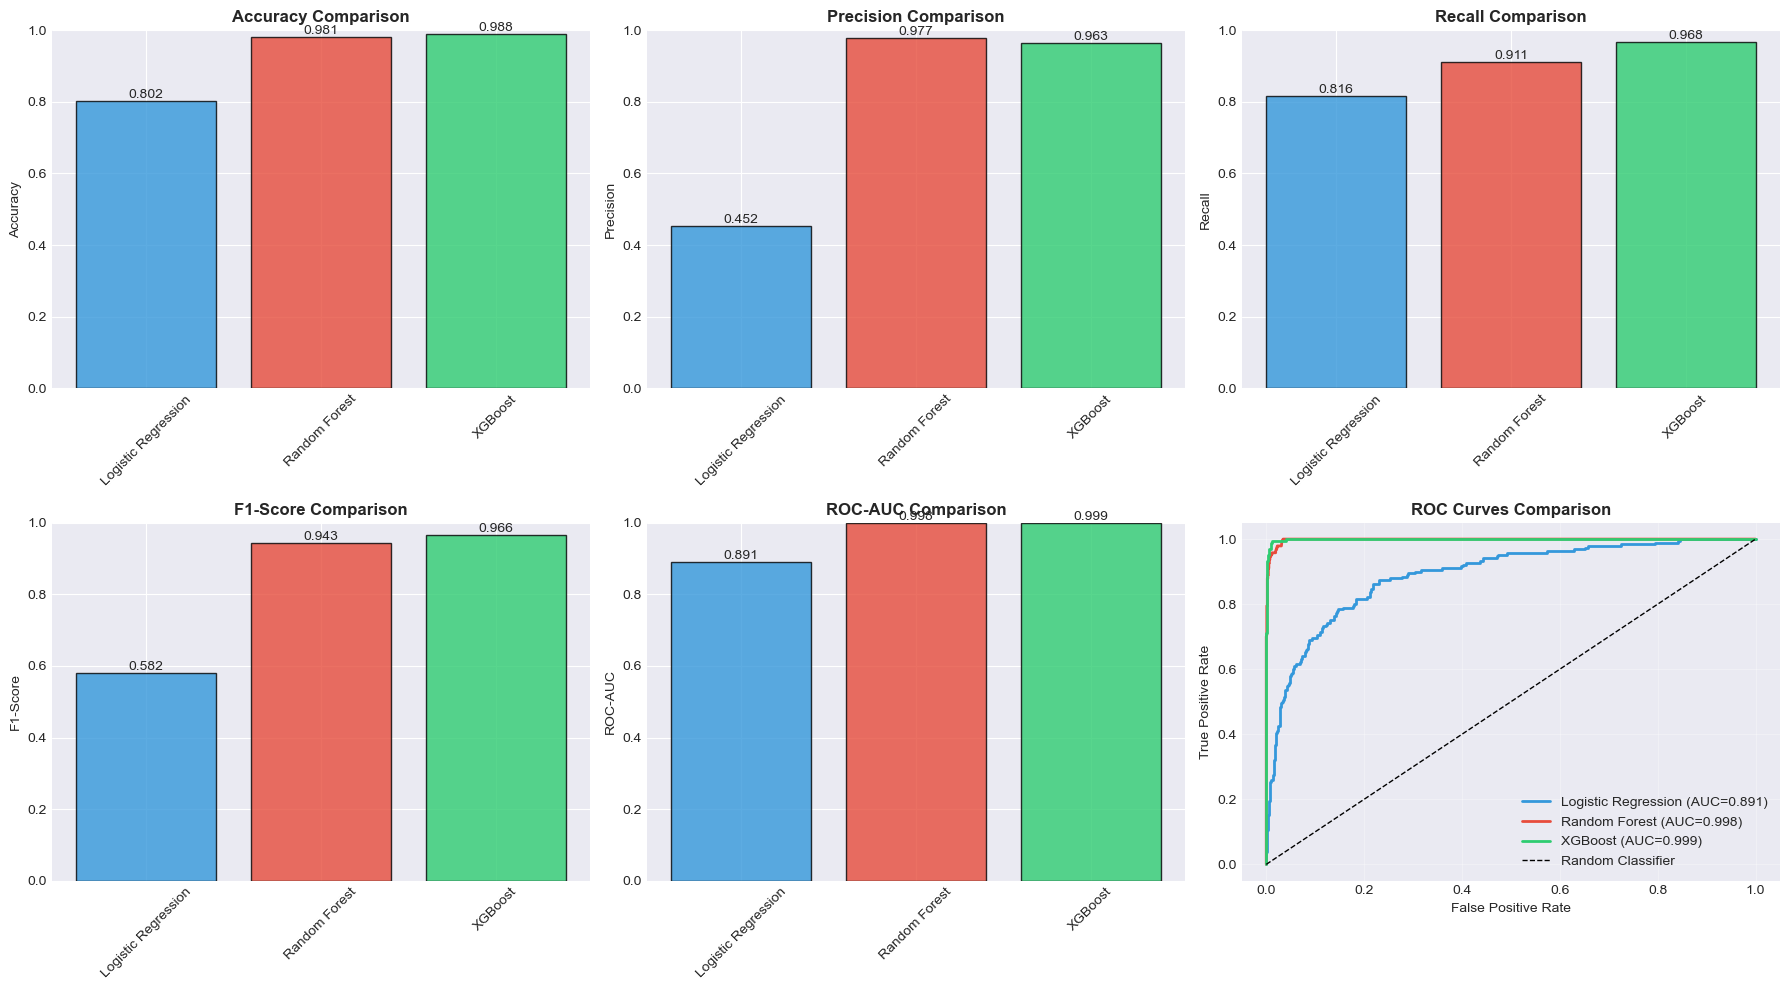


KEY INSIGHTS

Model Strengths:
   - Best Overall Performance: XGBoost (ROC-AUC: 0.9991)
   - Best Precision: Random Forest (0.9774)
   - Best Recall: XGBoost (0.9684)
   - Best F1-Score: XGBoost (0.9659)


In [61]:
print("\n" + "="*80)
print("MODEL COMPARISON & FINAL RESULTS")
print("="*80)

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
})

print("\nMODEL PERFORMANCE COMPARISON")
print("="*80)
print(model_comparison.to_string(index=False))

# Find best model
best_model_idx = model_comparison['ROC-AUC'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_roc_auc = model_comparison.loc[best_model_idx, 'ROC-AUC']

print(f"\nBEST MODEL: {best_model_name}")
print(f"   ROC-AUC Score: {best_roc_auc:.4f}")

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    
    ax = axes[row, col]
    bars = ax.bar(model_comparison['Model'], model_comparison[metric], color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

# ROC Curve comparison
ax = axes[1, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})', 
        linewidth=2, color=colors[0])
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})', 
        linewidth=2, color=colors[1])
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_pred_proba_xgb):.3f})', 
        linewidth=2, color=colors[2])
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print("\nModel Strengths:")
print(f"   - Best Overall Performance: {best_model_name} (ROC-AUC: {best_roc_auc:.4f})")
print(f"   - Best Precision: {model_comparison.loc[model_comparison['Precision'].idxmax(), 'Model']} ({model_comparison['Precision'].max():.4f})")
print(f"   - Best Recall: {model_comparison.loc[model_comparison['Recall'].idxmax(), 'Model']} ({model_comparison['Recall'].max():.4f})")
print(f"   - Best F1-Score: {model_comparison.loc[model_comparison['F1-Score'].idxmax(), 'Model']} ({model_comparison['F1-Score'].max():.4f})")

In [62]:
print("\n" + "="*80)
print("SAVE MODELS & FINAL SUMMARY")
print("="*80)

# Save models using joblib
import joblib

# Save all models
model_files = {
    'logistic_regression_model.pkl': best_lr,
    'random_forest_model.pkl': best_rf,
    'xgboost_model.pkl': best_xgb,
    'scaler.pkl': scaler
}

print("\nSaving trained models...")
for filename, model in model_files.items():
    joblib.dump(model, filename)
    print(f"   - {filename}")

# Save model comparison results
model_comparison.to_csv('model_comparison_results.csv', index=False)
print("\n- Model comparison saved to: model_comparison_results.csv")

# Save feature importance from best tree-based model
if best_model_name == 'Random Forest':
    feature_importance_rf.to_csv('feature_importance.csv', index=False)
    print("- Feature importance saved to: feature_importance.csv")
elif best_model_name == 'XGBoost':
    feature_importance_xgb.to_csv('feature_importance.csv', index=False)
    print("- Feature importance saved to: feature_importance.csv")

# Create final summary report
summary_report = f"""
{'='*80}
CHURN PREDICTION MODEL - FINAL SUMMARY REPORT
{'='*80}

Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET INFORMATION
{'='*80}
Total Samples: {len(df_model):,}
Training Samples: {len(X_train):,} ({len(X_train)/len(df_model)*100:.1f}%)
Test Samples: {len(X_test):,} ({len(X_test)/len(df_model)*100:.1f}%)
Total Features: {X.shape[1]}
Churn Rate: {y.mean():.2%}

MODELS TRAINED
{'='*80}
1. Logistic Regression (with L1/L2 regularization)
2. Random Forest (ensemble tree-based)
3. XGBoost (gradient boosting)

All models trained with:
- 5-fold Stratified Cross-Validation
- GridSearchCV for hyperparameter tuning
- Class balancing for imbalanced data
- ROC-AUC as primary metric

BEST MODEL: {best_model_name}
{'='*80}
ROC-AUC Score: {best_roc_auc:.4f}
Accuracy: {model_comparison.loc[best_model_idx, 'Accuracy']:.4f}
Precision: {model_comparison.loc[best_model_idx, 'Precision']:.4f}
Recall: {model_comparison.loc[best_model_idx, 'Recall']:.4f}
F1-Score: {model_comparison.loc[best_model_idx, 'F1-Score']:.4f}

ALL MODELS PERFORMANCE
{'='*80}
{model_comparison.to_string(index=False)}


{'='*80}
"""

print(summary_report)


print("\nSummary report saved to: model_summary_report.txt")


SAVE MODELS & FINAL SUMMARY

Saving trained models...
   - logistic_regression_model.pkl
   - random_forest_model.pkl
   - xgboost_model.pkl
   - scaler.pkl

- Model comparison saved to: model_comparison_results.csv
- Feature importance saved to: feature_importance.csv

CHURN PREDICTION MODEL - FINAL SUMMARY REPORT

Date: 2026-02-09 16:37:17

DATASET INFORMATION
Total Samples: 5,630
Training Samples: 4,504 (80.0%)
Test Samples: 1,126 (20.0%)
Total Features: 61
Churn Rate: 16.84%

MODELS TRAINED
1. Logistic Regression (with L1/L2 regularization)
2. Random Forest (ensemble tree-based)
3. XGBoost (gradient boosting)

All models trained with:
- 5-fold Stratified Cross-Validation
- GridSearchCV for hyperparameter tuning
- Class balancing for imbalanced data
- ROC-AUC as primary metric

BEST MODEL: XGBoost
ROC-AUC Score: 0.9991
Accuracy: 0.9885
Precision: 0.9634
Recall: 0.9684
F1-Score: 0.9659

ALL MODELS PERFORMANCE
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logist

## 14. Feature Importance Analysis

Analyzing which features are most important for predicting customer churn across all models.

In [64]:
print("="*80)
print("COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# ============================================================================
# 1. LOGISTIC REGRESSION - Coefficient-based Importance
# ============================================================================
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION - FEATURE COEFFICIENTS")
print("="*80)

# Get absolute coefficients as importance measure
lr_coefficients = np.abs(best_lr.coef_[0])
feature_importance_lr = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_lr.coef_[0],
    'Abs_Coefficient': lr_coefficients,
    'Importance_Rank': pd.Series(lr_coefficients).rank(ascending=False)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 20 Most Important Features (by absolute coefficient):")
print(feature_importance_lr.head(20).to_string(index=False))

print(f"\nInterpretation Guide:")
print(f"  • Positive coefficient → Feature increases churn probability")
print(f"  • Negative coefficient → Feature decreases churn probability")
print(f"  • Larger absolute value → Stronger impact on predictions")


# ============================================================================
# 2. RANDOM FOREST - Feature Importance
# ============================================================================
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST - FEATURE IMPORTANCE")
print("="*80)

feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_,
    'Importance_Rank': pd.Series(best_rf.feature_importances_).rank(ascending=False)
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance_rf.head(20).to_string(index=False))

print(f"\nInterpretation Guide:")
print(f"  • Higher importance → Feature is more useful for splitting data")
print(f"  • Based on Gini impurity reduction across all trees")


# ============================================================================
# 3. XGBOOST - Feature Importance
# ============================================================================
print("\n" + "="*80)
print("MODEL 3: XGBOOST - FEATURE IMPORTANCE")
print("="*80)

feature_importance_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_xgb.feature_importances_,
    'Importance_Rank': pd.Series(best_xgb.feature_importances_).rank(ascending=False)
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance_xgb.head(20).to_string(index=False))

print(f"\nInterpretation Guide:")
print(f"  • Higher importance → Feature contributes more to predictions")
print(f"  • Based on total gain from splits using this feature")


# ============================================================================
# 4. CONSOLIDATED FEATURE IMPORTANCE RANKING
# ============================================================================
print("\n" + "="*80)
print("CONSOLIDATED FEATURE IMPORTANCE - ALL MODELS")
print("="*80)

# Merge all importance rankings
consolidated = feature_importance_lr[['Feature', 'Importance_Rank']].copy()
consolidated.columns = ['Feature', 'LR_Rank']
consolidated = consolidated.merge(
    feature_importance_rf[['Feature', 'Importance_Rank']].rename(columns={'Importance_Rank': 'RF_Rank'}),
    on='Feature'
)
consolidated = consolidated.merge(
    feature_importance_xgb[['Feature', 'Importance_Rank']].rename(columns={'Importance_Rank': 'XGB_Rank'}),
    on='Feature'
)

# Calculate average rank across all models
consolidated['Avg_Rank'] = consolidated[['LR_Rank', 'RF_Rank', 'XGB_Rank']].mean(axis=1)
consolidated = consolidated.sort_values('Avg_Rank')

# Add importance values
consolidated = consolidated.merge(
    feature_importance_lr[['Feature', 'Abs_Coefficient']].rename(columns={'Abs_Coefficient': 'LR_Importance'}),
    on='Feature'
)
consolidated = consolidated.merge(
    feature_importance_rf[['Feature', 'Importance']].rename(columns={'Importance': 'RF_Importance'}),
    on='Feature'
)
consolidated = consolidated.merge(
    feature_importance_xgb[['Feature', 'Importance']].rename(columns={'Importance': 'XGB_Importance'}),
    on='Feature'
)

print("\nTop 25 Features (ranked by average importance across all models):")
print(consolidated.head(25).to_string(index=False))

# ============================================================================
# 5. FEATURE CATEGORY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*80)

# Categorize features
def categorize_feature(feature_name):
    feature_lower = feature_name.lower()
    if any(x in feature_lower for x in ['tenure', 'loyal', 'new_customer']):
        return 'Tenure & Lifecycle'
    elif any(x in feature_lower for x in ['engagement', 'app', 'device', 'hour']):
        return 'Engagement & Activity'
    elif any(x in feature_lower for x in ['rfm', 'recency', 'frequency', 'monetary']):
        return 'RFM Metrics'
    elif any(x in feature_lower for x in ['complain', 'satisfaction', 'discount', 'cashback', 'coupon']):
        return 'Customer Experience'
    elif any(x in feature_lower for x in ['clv', 'risk', 'value']):
        return 'Customer Value & Risk'
    elif any(x in feature_lower for x in ['order', 'days', 'amount']):
        return 'Purchase Behavior'
    elif any(x in feature_lower for x in ['city', 'warehouse', 'address', 'gender', 'marital']):
        return 'Demographics'
    elif any(x in feature_lower for x in ['payment', 'credit', 'cash', 'digital']):
        return 'Payment Preferences'
    elif any(x in feature_lower for x in ['mobile', 'laptop', 'fashion', 'prefered']):
        return 'Product Preferences'
    else:
        return 'Other'

consolidated['Category'] = consolidated['Feature'].apply(categorize_feature)

# Group by category
category_summary = consolidated.groupby('Category').agg({
    'Avg_Rank': 'mean',
    'Feature': 'count',
    'LR_Importance': 'mean',
    'RF_Importance': 'mean',
    'XGB_Importance': 'mean'
}).round(4)

category_summary.columns = ['Avg_Rank', 'Feature_Count', 'Avg_LR_Imp', 'Avg_RF_Imp', 'Avg_XGB_Imp']
category_summary = category_summary.sort_values('Avg_Rank')

print("\nFeature Category Summary (lower rank = more important):")
print(category_summary.to_string())

# ============================================================================
# 6. TOP FEATURES CONSENSUS
# ============================================================================
print("\n" + "="*80)
print("TOP FEATURES - MODEL CONSENSUS")
print("="*80)

# Features that rank in top 20 across ALL models
top_20_consensus = consolidated[
    (consolidated['LR_Rank'] <= 20) & 
    (consolidated['RF_Rank'] <= 20) & 
    (consolidated['XGB_Rank'] <= 20)
].sort_values('Avg_Rank')

if len(top_20_consensus) > 0:
    print(f"\n✓ {len(top_20_consensus)} features ranked in TOP 20 by ALL models:")
    print(top_20_consensus[['Feature', 'Category', 'LR_Rank', 'RF_Rank', 'XGB_Rank', 'Avg_Rank']].to_string(index=False))
else:
    print("\n⚠ No features ranked in top 20 by all three models")
    
# Features in top 10
top_10_consensus = consolidated[
    (consolidated['LR_Rank'] <= 10) | 
    (consolidated['RF_Rank'] <= 10) | 
    (consolidated['XGB_Rank'] <= 10)
].sort_values('Avg_Rank')

print(f"\n✓ {len(top_10_consensus)} features ranked in TOP 10 by at least one model:")
print(top_10_consensus[['Feature', 'Category', 'LR_Rank', 'RF_Rank', 'XGB_Rank']].head(15).to_string(index=False))

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS COMPLETED!")
print("="*80)

COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS

MODEL 1: LOGISTIC REGRESSION - FEATURE COEFFICIENTS

Top 20 Most Important Features (by absolute coefficient):
                 Feature  Coefficient  Abs_Coefficient  Importance_Rank
            Tenure_Years        -1.00             1.00             1.00
                  Tenure        -1.00             1.00             2.00
       SatisfactionScore         0.91             0.91             3.00
        PreferedOrderCat         0.67             0.67             4.00
       Is_Loyal_Customer         0.66             0.66             5.00
Sat_Complain_Interaction        -0.65             0.65             6.00
NumberOfDeviceRegistered         0.63             0.63             7.00
         NumberOfAddress         0.60             0.60             8.00
          Prefers_Laptop        -0.59             0.59             9.00
                Complain         0.49             0.49            10.00
              CouponUsed         0.44             0.44


FEATURE IMPORTANCE VISUALIZATIONS


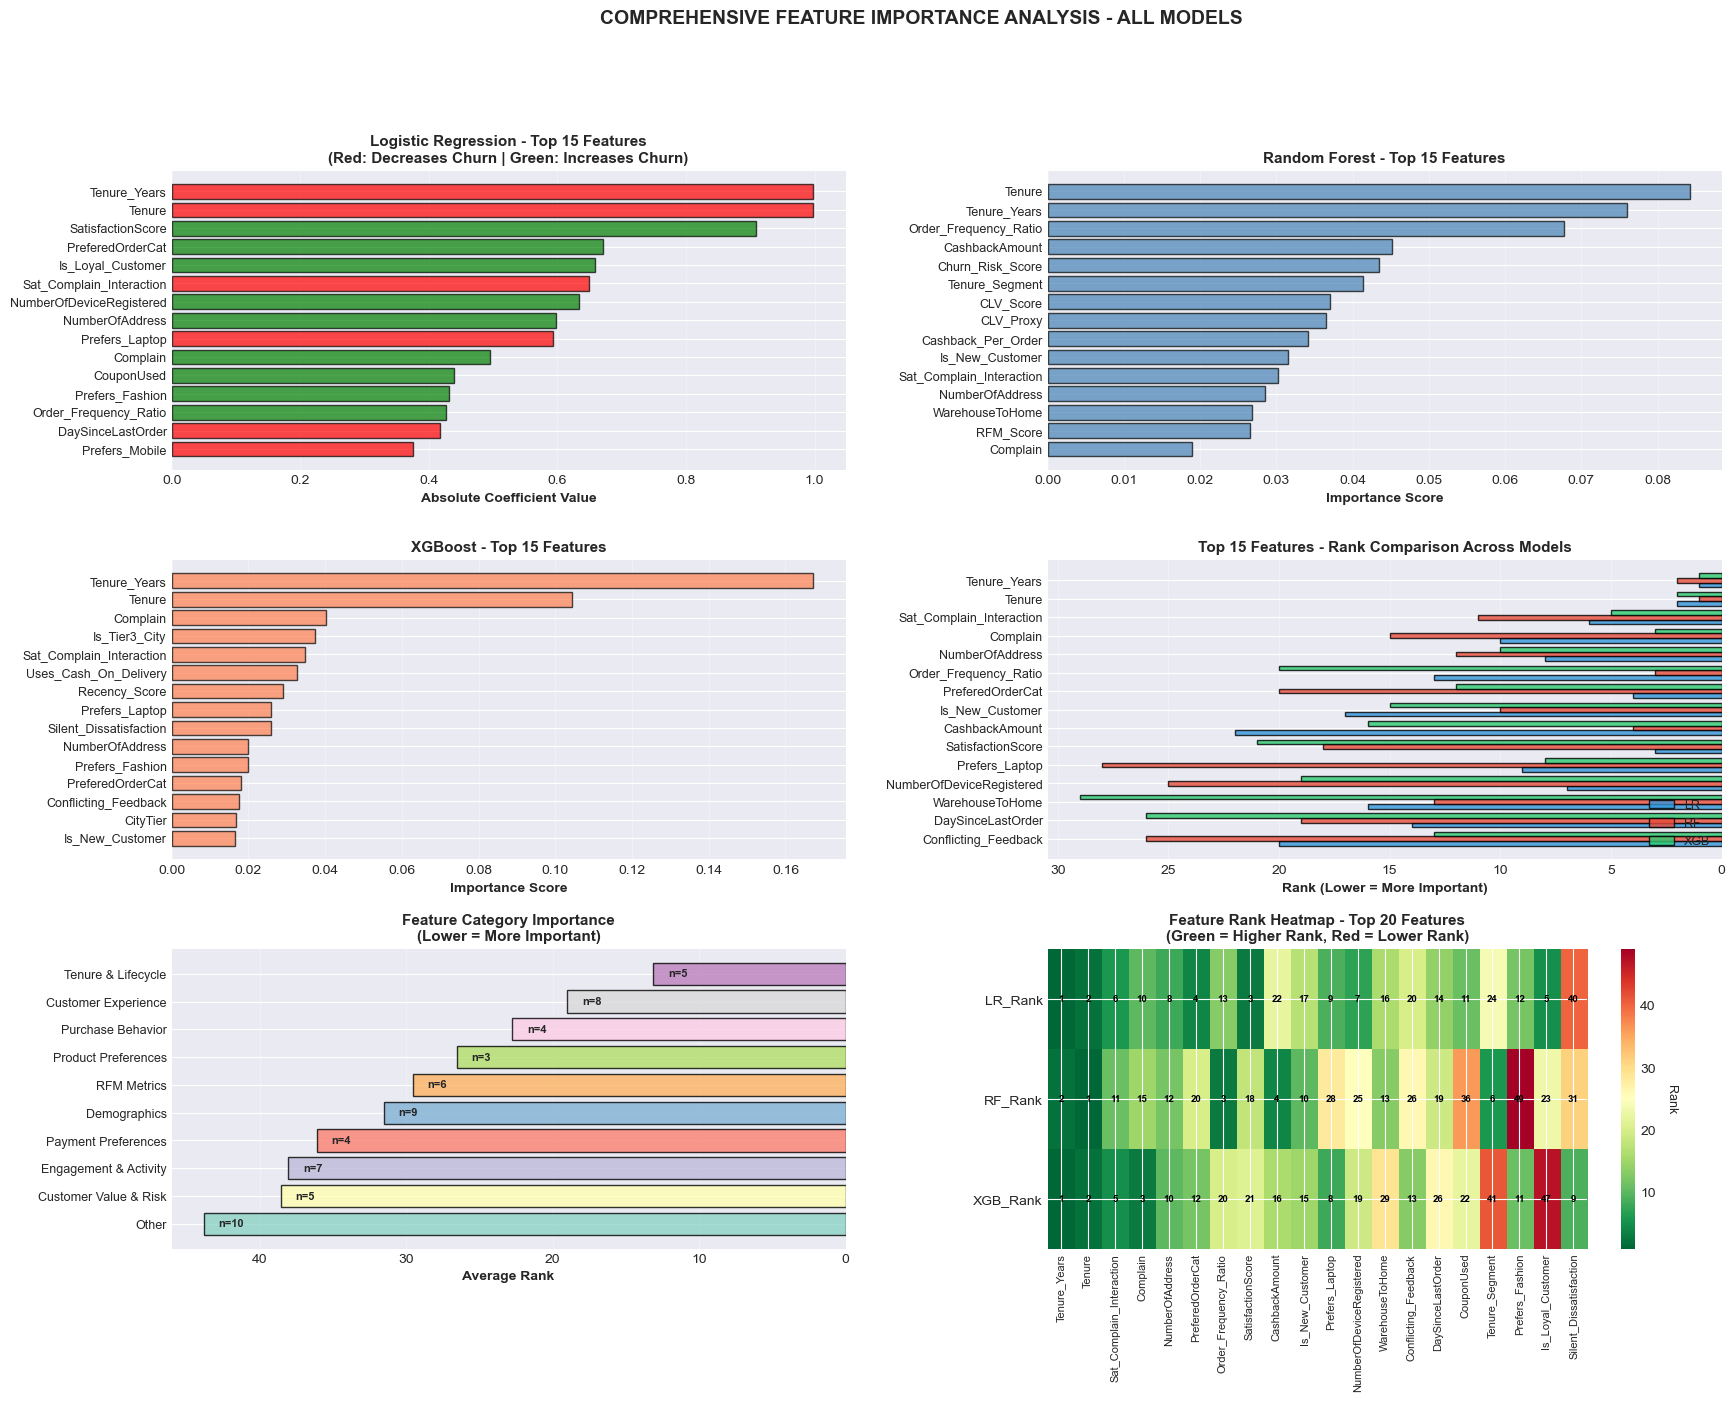


✓ Visualizations generated successfully!


In [65]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATIONS")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ============================================================================
# 1. Logistic Regression - Top 15 Features
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
top_lr = feature_importance_lr.head(15).sort_values('Abs_Coefficient')
colors_lr = ['red' if x < 0 else 'green' for x in top_lr['Coefficient']]
ax1.barh(range(len(top_lr)), top_lr['Abs_Coefficient'], color=colors_lr, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top_lr)))
ax1.set_yticklabels(top_lr['Feature'], fontsize=9)
ax1.set_xlabel('Absolute Coefficient Value', fontsize=10, fontweight='bold')
ax1.set_title('Logistic Regression - Top 15 Features\n(Red: Decreases Churn | Green: Increases Churn)', 
              fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# ============================================================================
# 2. Random Forest - Top 15 Features
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])
top_rf = feature_importance_rf.head(15).sort_values('Importance')
ax2.barh(range(len(top_rf)), top_rf['Importance'], color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(top_rf)))
ax2.set_yticklabels(top_rf['Feature'], fontsize=9)
ax2.set_xlabel('Importance Score', fontsize=10, fontweight='bold')
ax2.set_title('Random Forest - Top 15 Features', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# ============================================================================
# 3. XGBoost - Top 15 Features
# ============================================================================
ax3 = fig.add_subplot(gs[1, 0])
top_xgb = feature_importance_xgb.head(15).sort_values('Importance')
ax3.barh(range(len(top_xgb)), top_xgb['Importance'], color='coral', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(top_xgb)))
ax3.set_yticklabels(top_xgb['Feature'], fontsize=9)
ax3.set_xlabel('Importance Score', fontsize=10, fontweight='bold')
ax3.set_title('XGBoost - Top 15 Features', fontsize=11, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# ============================================================================
# 4. Top 15 Consolidated Features (Average Rank)
# ============================================================================
ax4 = fig.add_subplot(gs[1, 1])
top_consolidated = consolidated.head(15).sort_values('Avg_Rank', ascending=False)

# Create grouped bar chart
x_pos = np.arange(len(top_consolidated))
width = 0.25

bars1 = ax4.barh(x_pos - width, top_consolidated['LR_Rank'], width, label='LR', 
                 color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax4.barh(x_pos, top_consolidated['RF_Rank'], width, label='RF', 
                 color='#e74c3c', alpha=0.8, edgecolor='black')
bars3 = ax4.barh(x_pos + width, top_consolidated['XGB_Rank'], width, label='XGB', 
                 color='#2ecc71', alpha=0.8, edgecolor='black')

ax4.set_yticks(x_pos)
ax4.set_yticklabels(top_consolidated['Feature'], fontsize=9)
ax4.set_xlabel('Rank (Lower = More Important)', fontsize=10, fontweight='bold')
ax4.set_title('Top 15 Features - Rank Comparison Across Models', fontsize=11, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.invert_xaxis()  # Lower rank on right
ax4.grid(axis='x', alpha=0.3)

# ============================================================================
# 5. Feature Category Importance
# ============================================================================
ax5 = fig.add_subplot(gs[2, 0])
category_plot = category_summary.sort_values('Avg_Rank', ascending=False)
colors_cat = plt.cm.Set3(range(len(category_plot)))
ax5.barh(range(len(category_plot)), category_plot['Avg_Rank'], color=colors_cat, 
         alpha=0.8, edgecolor='black')
ax5.set_yticks(range(len(category_plot)))
ax5.set_yticklabels(category_plot.index, fontsize=9)
ax5.set_xlabel('Average Rank', fontsize=10, fontweight='bold')
ax5.set_title('Feature Category Importance\n(Lower = More Important)', fontsize=11, fontweight='bold')
ax5.invert_xaxis()
ax5.grid(axis='x', alpha=0.3)

# Add count labels
for i, (idx, row) in enumerate(category_plot.iterrows()):
    ax5.text(row['Avg_Rank'] - 1, i, f"n={int(row['Feature_Count'])}", 
            va='center', fontsize=8, fontweight='bold')

# ============================================================================
# 6. Model Agreement Heatmap
# ============================================================================
ax6 = fig.add_subplot(gs[2, 1])

# Get top 20 features and their ranks
top_20_all = consolidated.head(20)[['Feature', 'LR_Rank', 'RF_Rank', 'XGB_Rank']].set_index('Feature')
top_20_all = top_20_all.T

# Create heatmap
im = ax6.imshow(top_20_all.values, cmap='RdYlGn_r', aspect='auto')

# Set ticks and labels
ax6.set_xticks(range(len(top_20_all.columns)))
ax6.set_xticklabels(top_20_all.columns, rotation=90, fontsize=8)
ax6.set_yticks(range(len(top_20_all.index)))
ax6.set_yticklabels(top_20_all.index, fontsize=10)
ax6.set_title('Feature Rank Heatmap - Top 20 Features\n(Green = Higher Rank, Red = Lower Rank)', 
              fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax6)
cbar.set_label('Rank', rotation=270, labelpad=15, fontsize=9)

# Add text annotations
for i in range(len(top_20_all.index)):
    for j in range(len(top_20_all.columns)):
        text = ax6.text(j, i, f'{int(top_20_all.iloc[i, j])}',
                       ha="center", va="center", color="black", fontsize=7, fontweight='bold')

plt.suptitle('COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS - ALL MODELS', 
             fontsize=14, fontweight='bold', y=0.995)

plt.show()

print("\n✓ Visualizations generated successfully!")

In [66]:
print("\n" + "="*80)
print("EXPORT FEATURE IMPORTANCE RESULTS")
print("="*80)

# Export individual model feature importances
feature_importance_lr.to_csv('feature_importance_logistic_regression.csv', index=False)
print("✓ Saved: feature_importance_logistic_regression.csv")

feature_importance_rf.to_csv('feature_importance_random_forest.csv', index=False)
print("✓ Saved: feature_importance_random_forest.csv")

feature_importance_xgb.to_csv('feature_importance_xgboost.csv', index=False)
print("✓ Saved: feature_importance_xgboost.csv")

# Export consolidated rankings
consolidated.to_csv('feature_importance_consolidated.csv', index=False)
print("✓ Saved: feature_importance_consolidated.csv")

# Export category summary
category_summary.to_csv('feature_importance_by_category.csv')
print("✓ Saved: feature_importance_by_category.csv")

# Create a comprehensive summary report
feature_summary_report = f"""
{'='*80}
FEATURE IMPORTANCE SUMMARY REPORT
{'='*80}

Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Total Features Analyzed: {len(feature_cols)}

{'='*80}
TOP 10 MOST IMPORTANT FEATURES (CONSENSUS)
{'='*80}

{consolidated.head(10)[['Feature', 'Category', 'Avg_Rank', 'LR_Rank', 'RF_Rank', 'XGB_Rank']].to_string(index=False)}

{'='*80}
FEATURE CATEGORY RANKINGS
{'='*80}

{category_summary.to_string()}

{'='*80}
KEY INSIGHTS
{'='*80}

Most Important Feature Categories:
{chr(10).join([f"  {i+1}. {cat} (Avg Rank: {row['Avg_Rank']:.1f}, {int(row['Feature_Count'])} features)" 
               for i, (cat, row) in enumerate(category_summary.head(5).iterrows())])}

Top 5 Individual Features:
{chr(10).join([f"  {i+1}. {row['Feature']} ({row['Category']}) - Avg Rank: {row['Avg_Rank']:.1f}" 
               for i, (idx, row) in enumerate(consolidated.head(5).iterrows())])}

Model Agreement:
  • Features in ALL top 20: {len(top_20_consensus)}
  • Features in ANY top 10: {len(top_10_consensus)}

{'='*80}
BUSINESS RECOMMENDATIONS
{'='*80}

Based on feature importance analysis:

1. PRIORITY ACTIONS:
   Focus on the top-ranked features for intervention strategies
   {chr(10).join([f"   • {row['Feature']}: {row['Category']}" 
                  for idx, row in consolidated.head(3).iterrows()])}

2. MONITORING:
   Track changes in high-importance features for early churn signals
   
3. CUSTOMER SEGMENTATION:
   Use important features to create targeted retention campaigns

4. DATA COLLECTION:
   Ensure high-quality data capture for most important features

{'='*80}
"""

# Save summary report
with open('feature_importance_summary_report.txt', 'w') as f:
    f.write(feature_summary_report)

print("✓ Saved: feature_importance_summary_report.txt")

print("\n" + "="*80)
print("ALL FEATURE IMPORTANCE RESULTS EXPORTED SUCCESSFULLY!")
print("="*80)

print("\nExported Files:")
print("  1. feature_importance_logistic_regression.csv")
print("  2. feature_importance_random_forest.csv")
print("  3. feature_importance_xgboost.csv")
print("  4. feature_importance_consolidated.csv")
print("  5. feature_importance_by_category.csv")
print("  6. feature_importance_summary_report.txt")

# Display the summary report
print("\n" + feature_summary_report)


EXPORT FEATURE IMPORTANCE RESULTS
✓ Saved: feature_importance_logistic_regression.csv
✓ Saved: feature_importance_random_forest.csv
✓ Saved: feature_importance_xgboost.csv
✓ Saved: feature_importance_consolidated.csv
✓ Saved: feature_importance_by_category.csv
✓ Saved: feature_importance_summary_report.txt

ALL FEATURE IMPORTANCE RESULTS EXPORTED SUCCESSFULLY!

Exported Files:
  1. feature_importance_logistic_regression.csv
  2. feature_importance_random_forest.csv
  3. feature_importance_xgboost.csv
  4. feature_importance_consolidated.csv
  5. feature_importance_by_category.csv
  6. feature_importance_summary_report.txt


FEATURE IMPORTANCE SUMMARY REPORT

Date: 2026-02-09 16:41:59
Total Features Analyzed: 61

TOP 10 MOST IMPORTANT FEATURES (CONSENSUS)

                 Feature            Category  Avg_Rank  LR_Rank  RF_Rank  XGB_Rank
            Tenure_Years  Tenure & Lifecycle      1.33     1.00     2.00      1.00
                  Tenure  Tenure & Lifecycle      1.67     2.00    